In [1]:

from pathlib import Path
import os
RUNNER_SECTION = '05_heston_fullinfo_true_vol'
RUNNER_RUN_DIR = Path('/content/drive/MyDrive/MFE_neural_hedging_report_outputs/source_runs/05_heston_fullinfo_true_vol')
RUNNER_RUN_DIR.mkdir(parents=True, exist_ok=True)
print("Runner section:", RUNNER_SECTION)
print("Runner run dir:", RUNNER_RUN_DIR)
os.chdir(RUNNER_RUN_DIR)

print("Heston runner mode: full-information / true simulated variance")

Runner section: 05_heston_fullinfo_true_vol
Runner run dir: /content/drive/MyDrive/MFE_neural_hedging_report_outputs/source_runs/05_heston_fullinfo_true_vol
Heston runner mode: full-information / true simulated variance



# Heston Delta--Vega Neural Hedging Extension

This notebook implements a report-ready multi-instrument neural hedging extension:

\[
\text{Heston stock dynamics} + \text{stock and liquid option as hedging instruments}.
\]

The goal is to move beyond the frictionless Black--Scholes setting, where the stock alone spans the single Brownian risk factor. Under Heston dynamics, the stock price is driven by stochastic variance, so the target option is exposed to both underlying-price risk and volatility/variance risk.

A second traded option is therefore interpreted primarily as a **vega hedging instrument**, rather than merely a gamma hedge.

The Heston dynamics are

\[
dS_t = rS_t\,dt + \sqrt{v_t}S_t\,dW_t^S,
\]

\[
dv_t = \kappa(\theta-v_t)\,dt + \xi\sqrt{v_t}\,dW_t^v,
\]

with

\[
dW_t^S dW_t^v = \rho\,dt.
\]

The stock-and-option terminal wealth is

\[
V_T
=
\pi
+
\sum_{n=0}^{N-1}\delta_n(S_{t_{n+1}}-S_{t_n})
+
\sum_{n=0}^{N-1}\eta_n(C^h_{t_{n+1}}-C^h_{t_n}),
\]

where \(C^h\) is a liquid hedging option and the neural network outputs

\[
(\delta_n,\eta_n).
\]

## Important modelling note

In this revised COS version, the liquid hedging option is priced consistently under the Heston model using a Fourier--cosine (COS) pricing routine:

\[
C^h_t =
C_{\mathrm{Heston,COS}}(S_t,v_t,K_h,T_h-t).
\]

This replaces the earlier Black--Scholes instantaneous-volatility proxy. The old proxy delta--vega rule is re-evaluated later as a same-path diagnostic only; it is not the primary Heston-consistent benchmark.


> **Revision note:** A technical-review revision block has been appended at the end of this notebook to add proxy-drift diagnostics, stock-only tanh control, fair-premium evaluation, and revised report outputs.

> **Second revision note:** The interpretation has been corrected so that raw Mean HE is no longer treated as a primary proxy-drift detector. A superseded-results banner and optional multi-seed headline robustness cell have also been added.

## Notebook correction note

This corrected version makes the COS/Carr--Madan validation reproducible inside the notebook, removes the previous over-strong validation claim, records the known short-maturity limitation of the fixed COS truncation, and adds mode-suffixed output archiving to distinguish full-information and observable-volatility runs.

In [2]:

# ============================================================
# Configuration
# ============================================================

RUN_FULL = True

# Target option and grid
S0 = 1.0
K_TARGET = 0.9
T_TARGET = 0.5
R = 0.0
N_STEPS = 125

# Heston parameters
V0 = 0.16          # initial variance, sqrt(V0)=0.40
KAPPA = 2.0       # mean reversion speed
THETA = 0.16      # long-run variance
XI = 0.60         # vol-of-vol
RHO = -0.70       # spot/vol correlation

# Liquid hedging option proxy.
# It should mature after the target option so it remains tradeable over [0,T_TARGET].
K_HEDGE = 1.0
T_HEDGE = 1.0

# Neural architecture
HIDDEN_WIDTH = 64
HIDDEN_DEPTH = 3
DELTA_SCALE = 5.0      # stock-position output range: approximately [-5,5]
ETA_SCALE = 5.0        # option-position output range: approximately [-5,5]

# Greek proxy clipping for stability
DELTA_CLIP = 5.0
ETA_CLIP = 5.0

# Sensitivity-only wider clip for the analytic Heston COS delta--vega benchmark.
# This is NOT the primary comparison because the NN output range remains [-5,5].
DV_SENSITIVITY_CLIP = 20.0

# Training sizes
if RUN_FULL:
    N_TRAIN = 100_000
    N_VAL = 25_000
    N_TEST = 100_000
    MAX_EPOCHS = 150
    BATCH_SIZE = 4096
    PATIENCE = 30
else:
    N_TRAIN = 20_000
    N_VAL = 10_000
    N_TEST = 50_000
    MAX_EPOCHS = 60
    BATCH_SIZE = 2048
    PATIENCE = 15

LEARNING_RATE = 1e-3
SEED = 123

OUTPUT_DIR = "heston_delta_vega_outputs"
RESULTS_CSV = "heston_delta_vega_results.csv"

# ------------------------------------------------------------
# Observable-volatility ablation (fairness of conditioning on v_t).
# v_t is latent under Heston. With this flag True, every hedging rule
# (NN inputs AND analytic benchmark Greeks) conditions on an EWMA
# realized-variance proxy built from the stock path, instead of true v_t.
#
# IMPORTANT REPRODUCIBILITY NOTE:
# - USE_OBSERVABLE_VOL = False reproduces the full-information Heston headline.
# - USE_OBSERVABLE_VOL = True reproduces the observable-volatility robustness check.
# The final archive cell writes mode-suffixed copies of the outputs so the two
# runs cannot be confused after both have been executed.
# ------------------------------------------------------------
USE_OBSERVABLE_VOL = False
MODE_TAG = "obsvol" if USE_OBSERVABLE_VOL else "fullinfo"
EWMA_LAMBDA = 0.94           # EWMA decay; effective window ~ 1/(1-lambda) ~ 16 steps
print(f"Heston run mode: {MODE_TAG}")


Heston run mode: fullinfo


In [3]:

# ============================================================
# Imports and device
# ============================================================

import math
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)


Device: cuda


In [4]:

# ============================================================
# Black--Scholes proxy pricing utilities
# ============================================================

def norm_cdf(x):
    return 0.5 * (1.0 + torch.erf(x / math.sqrt(2.0)))


def norm_pdf(x):
    return torch.exp(-0.5 * x * x) / math.sqrt(2.0 * math.pi)


def bs_call_price(S, K, tau, vol, r=R):
    """
    Vectorised Black--Scholes call price.
    S, tau and vol can be tensors with broadcast-compatible shapes.
    """
    tau = torch.as_tensor(tau, dtype=S.dtype, device=S.device)
    vol = torch.as_tensor(vol, dtype=S.dtype, device=S.device)

    tau_safe = torch.clamp(tau, min=1e-10)
    vol_safe = torch.clamp(vol, min=1e-6)
    sqrt_tau = torch.sqrt(tau_safe)

    d1 = (torch.log(torch.clamp(S, min=1e-12) / K) + (r + 0.5 * vol_safe**2) * tau_safe) / (vol_safe * sqrt_tau)
    d2 = d1 - vol_safe * sqrt_tau

    disc_K = K * torch.exp(torch.tensor(-r, dtype=S.dtype, device=S.device) * tau_safe)
    price = S * norm_cdf(d1) - disc_K * norm_cdf(d2)
    payoff = torch.clamp(S - K, min=0.0)
    return torch.where(tau > 1e-8, price, payoff)


def bs_delta(S, K, tau, vol, r=R):
    tau = torch.as_tensor(tau, dtype=S.dtype, device=S.device)
    vol = torch.as_tensor(vol, dtype=S.dtype, device=S.device)

    tau_safe = torch.clamp(tau, min=1e-10)
    vol_safe = torch.clamp(vol, min=1e-6)
    sqrt_tau = torch.sqrt(tau_safe)

    d1 = (torch.log(torch.clamp(S, min=1e-12) / K) + (r + 0.5 * vol_safe**2) * tau_safe) / (vol_safe * sqrt_tau)
    delta = norm_cdf(d1)
    terminal_delta = (S > K).to(S.dtype)
    return torch.where(tau > 1e-8, delta, terminal_delta)


def bs_vega(S, K, tau, vol, r=R):
    """
    Black--Scholes vega with respect to volatility sigma.
    """
    tau = torch.as_tensor(tau, dtype=S.dtype, device=S.device)
    vol = torch.as_tensor(vol, dtype=S.dtype, device=S.device)

    tau_safe = torch.clamp(tau, min=1e-10)
    vol_safe = torch.clamp(vol, min=1e-6)
    sqrt_tau = torch.sqrt(tau_safe)

    d1 = (torch.log(torch.clamp(S, min=1e-12) / K) + (r + 0.5 * vol_safe**2) * tau_safe) / (vol_safe * sqrt_tau)
    vega = S * norm_pdf(d1) * sqrt_tau
    return torch.where(tau > 1e-8, vega, torch.zeros_like(S))


def scalar_bs_proxy_price(S0, K, T, vol0):
    S = torch.tensor(float(S0), device=device)
    tau = torch.tensor(float(T), device=device)
    vol = torch.tensor(float(vol0), device=device)
    return float(bs_call_price(S, K, tau, vol).detach().cpu())


In [5]:
# ============================================================
# Martingale-consistent Heston option pricing via the COS method
# (Fang & Oosterlee, 2008) with the little-Heston-trap CF.
# Replaces the Black--Scholes instantaneous-vol proxy for C^h, and
# supplies real Heston Greeks for the delta--vega benchmark.
# Numerical validation is performed in the next cell against an independent
# Carr--Madan Fourier-pricing implementation. In the traded liquid-option
# maturity range used for the headline experiment (tau_h in [0.5, 1.0]), the
# fixed-truncation COS implementation agrees with Carr--Madan to roughly 1e-8
# in the tested parameter regime. Accuracy can degrade for very short maturities
# and low variance under the fixed truncation interval, so near-expiry target
# COS Greeks should be interpreted as part of a local analytic benchmark rather
# than as exact finite-grid optimal hedge quantities.
# ============================================================

HESTON_PARAMS = dict(kappa=KAPPA, theta=THETA, xi=XI, rho=RHO, r=R)

_COS_N = 256            # number of cosine terms
_COS_A, _COS_B = -7.0, 7.0   # truncation interval in y = ln(S_T/K)

def _heston_Cc_D(u, tau, p):
    # CF of ln(S_T): phi(u)=exp(Cc + D*v + i*u*ln S); Cc includes r*i*u*tau.
    iu = 1j * u.to(torch.complex128)
    k, th, xi, rho, r = p["kappa"], p["theta"], p["xi"], p["rho"], p["r"]
    d   = torch.sqrt((rho*xi*iu - k)**2 + xi**2 * (iu + u.to(torch.complex128)**2))
    num = k - rho*xi*iu - d
    den = k - rho*xi*iu + d
    g   = num / den
    edt = torch.exp(-d * tau)
    D   = (num/xi**2) * (1 - edt) / (1 - g*edt)
    Cc  = r*iu*tau + (k*th/xi**2) * (num*tau - 2*torch.log((1 - g*edt)/(1 - g)))
    return Cc, D

def _heston_Vk(K, a, b, N, device):
    k   = torch.arange(N, device=device, dtype=torch.float64)
    kpi = k * math.pi / (b - a)
    def chi(c, d):
        return (1.0/(1 + kpi**2)) * (
            torch.cos(kpi*(d-a))*math.e**d - torch.cos(kpi*(c-a))*math.e**c
            + kpi*torch.sin(kpi*(d-a))*math.e**d - kpi*torch.sin(kpi*(c-a))*math.e**c)
    psi = torch.empty(N, device=device, dtype=torch.float64)
    psi[0]  = b
    psi[1:] = (torch.sin(kpi[1:]*(b-a)) - torch.sin(kpi[1:]*(-a))) / kpi[1:]
    Vk = (2.0/(b-a)) * K * (chi(0.0, b) - psi)
    Vk[0] *= 0.5
    return Vk

def heston_cos_price(S, v, K, tau, p=HESTON_PARAMS, N=_COS_N, a=_COS_A, b=_COS_B,
                     want_delta=False, want_dv=False):
    """Scalar K, tau; tensor S, v of any broadcastable shape. r=0 -> disc=1."""
    device = S.device
    Sd = S.to(torch.float64); vd = v.to(torch.float64)
    u  = torch.arange(N, device=device, dtype=torch.float64) * math.pi / (b - a)
    Cc, D = _heston_Cc_D(u, float(tau), p)
    Vk = _heston_Vk(K, a, b, N, device)
    disc = math.exp(-p["r"] * tau)
    x = torch.log(Sd.clamp_min(1e-12) / K)
    base = torch.exp(Cc + D*vd.unsqueeze(-1) + (1j*u)*(x.unsqueeze(-1) - a))
    price = disc * (base.real * Vk).sum(-1)
    out = [price.to(S.dtype)]
    if want_delta:
        out.append((disc * (((1j*u)*base).real * Vk).sum(-1) / Sd).to(S.dtype))
    if want_dv:
        out.append((disc * ((D*base).real * Vk).sum(-1)).to(S.dtype))
    return out[0] if len(out) == 1 else tuple(out)

@torch.no_grad()
def heston_C_h_paths_cos(S, v, Kh, T_hedge, times, p=HESTON_PARAMS, N=_COS_N):
    """Liquid-option price along all nodes. S,v:[B,L], times:[L] -> C_h:[B,L]."""
    L = S.shape[1]
    C_h = torch.empty_like(S)
    for j in range(L):
        C_h[:, j] = heston_cos_price(S[:, j], v[:, j], Kh, float(T_hedge - times[j]), p, N=N)
    return C_h

@torch.no_grad()
def heston_delta_vega_positions(S, v, times, p=HESTON_PARAMS,
                                K_target=K_TARGET, T_target=T_TARGET,
                                K_hedge=K_HEDGE, T_hedge=T_HEDGE,
                                delta_clip=DELTA_CLIP, eta_clip=ETA_CLIP, N=_COS_N):
    """Real Heston delta--vega benchmark via COS Greeks.
    Match instantaneous-variance exposure (dC/dv) with the option, residual delta
    with the stock (stock has dC/dS=1, dC/dv=0). Acts on hedging dates S[:,:-1]."""
    Sn = S[:, :-1]; vn = v[:, :-1]
    M = Sn.shape[1]
    delta = torch.empty_like(Sn); eta = torch.empty_like(Sn)
    for j in range(M):
        tt = float(T_target - times[j]); th = float(T_hedge - times[j])
        if tt <= 1e-8:
            dS_t = (Sn[:, j] > K_target).to(Sn.dtype); dv_t = torch.zeros_like(Sn[:, j])
        else:
            _, dS_t, dv_t = heston_cos_price(Sn[:, j], vn[:, j], K_target, tt, p,
                                             want_delta=True, want_dv=True, N=N)
        _, dS_h, dv_h = heston_cos_price(Sn[:, j], vn[:, j], K_hedge, th, p,
                                         want_delta=True, want_dv=True, N=N)
        dv_h_safe = torch.where(dv_h.abs() < 1e-6, torch.full_like(dv_h, 1e-6), dv_h)
        e = (dv_t / dv_h_safe).clamp(-eta_clip, eta_clip)
        delta[:, j] = (dS_t - e * dS_h).clamp(-delta_clip, delta_clip)
        eta[:, j]   = e
    return delta, eta

# quick self-check at inception
_c0 = heston_cos_price(torch.tensor([S0]), torch.tensor([V0]), K_HEDGE, T_HEDGE).item()
print(f"COS liquid-option price C_h(0) = {_c0:.6f} (BS proxy was ~0.158519)")


COS liquid-option price C_h(0) = 0.149458 (BS proxy was ~0.158519)


## Independent Carr--Madan cross-check for the Heston COS pricer

This cell makes the COS validation reproducible inside the notebook. The COS liquid-option path used for the main hedging experiment has remaining maturity $\tau_h\in[0.5,1.0]$. The validation below checks that regime directly and also records a short-maturity stress diagnostic, where the fixed COS truncation interval is known to be less reliable. The short-maturity diagnostic is included to prevent overclaiming about target-option Greeks near expiry.

In [6]:
# ============================================================
# Independent Carr--Madan cross-check for the Heston COS pricer
# ============================================================

# The COS pricer above is the production pricer used for C_h along the simulated
# Heston paths. This cell supplies an independent Fourier-pricing check so the
# validation claim is reproducible from the notebook. It does not change any
# hedging results unless the user deliberately modifies the production COS pricer.


def heston_cf_logS_carr_madan_np(z, S0_scalar, v0_scalar, tau, p=HESTON_PARAMS):
    """Independent NumPy Heston characteristic function for log S_T.

    This mirrors the little-Heston-trap form but is intentionally written outside
    the Torch COS implementation used above. It returns E[exp(i z log S_T)].
    """
    z = np.asarray(z, dtype=np.complex128)
    iz = 1j * z
    kappa, theta, xi, rho, r = p["kappa"], p["theta"], p["xi"], p["rho"], p["r"]

    d = np.sqrt((rho * xi * iz - kappa) ** 2 + xi ** 2 * (iz + z ** 2))
    num = kappa - rho * xi * iz - d
    den = kappa - rho * xi * iz + d
    g = num / den
    exp_dt = np.exp(-d * tau)

    D = (num / xi ** 2) * (1.0 - exp_dt) / (1.0 - g * exp_dt)
    C = r * iz * tau + (kappa * theta / xi ** 2) * (
        num * tau - 2.0 * np.log((1.0 - g * exp_dt) / (1.0 - g))
    )
    return np.exp(C + D * v0_scalar + iz * np.log(S0_scalar))


def heston_carr_madan_call_np(
    S0_scalar,
    v0_scalar,
    K_scalar,
    tau,
    p=HESTON_PARAMS,
    alpha=1.5,
    u_max=200.0,
    n_grid=20_000,
):
    """Carr--Madan damped Fourier call price for the Heston model.

    C(K) = exp(-alpha k)/pi * int_0^inf Re[exp(-iuk) psi(u)] du,
    where k=log K and
    psi(u)=exp(-r tau) phi(u-(alpha+1)i)/(alpha^2+alpha-u^2+i(2alpha+1)u).
    """
    if tau <= 1e-12:
        return float(max(S0_scalar - K_scalar, 0.0))

    u = np.linspace(1e-10, u_max, int(n_grid), dtype=np.float64)
    k_log = np.log(K_scalar)
    z = u - 1j * (alpha + 1.0)
    phi = heston_cf_logS_carr_madan_np(z, S0_scalar, v0_scalar, tau, p)
    denom = alpha ** 2 + alpha - u ** 2 + 1j * (2.0 * alpha + 1.0) * u
    psi = np.exp(-p["r"] * tau) * phi / denom
    integrand = np.real(np.exp(-1j * u * k_log) * psi)

    # np.trapezoid is preferred where available; np.trapz is kept as fallback.
    integral = np.trapezoid(integrand, u) if hasattr(np, "trapezoid") else np.trapz(integrand, u)
    return float(np.exp(-alpha * k_log) * integral / np.pi)


@torch.no_grad()
def run_cos_carr_madan_validation(
    S_grid=(0.8, 1.0, 1.2),
    v_grid=(0.08, 0.16, 0.32),
    tau_grid=(0.5, 0.75, 1.0),
    K_scalar=K_HEDGE,
):
    """Validate COS in the traded liquid-option maturity range tau_h in [0.5,1.0]."""
    rows = []
    for S_scalar in S_grid:
        for v_scalar in v_grid:
            for tau in tau_grid:
                S_t = torch.tensor([S_scalar], dtype=torch.float32, device=device)
                v_t = torch.tensor([v_scalar], dtype=torch.float32, device=device)
                cos_price = float(heston_cos_price(S_t, v_t, K_scalar, tau).detach().cpu().item())
                cm_price = heston_carr_madan_call_np(S_scalar, v_scalar, K_scalar, tau)
                rows.append({
                    "S": S_scalar,
                    "v": v_scalar,
                    "K": K_scalar,
                    "tau": tau,
                    "COS": cos_price,
                    "CarrMadan": cm_price,
                    "AbsError": abs(cos_price - cm_price),
                })
    df = pd.DataFrame(rows)
    print(
        "COS vs Carr--Madan over traded-option range tau in [0.5,1.0]: "
        f"max abs error = {df['AbsError'].max():.3e}, "
        f"median abs error = {df['AbsError'].median():.3e}"
    )
    return df


@torch.no_grad()
def run_short_maturity_cos_stress(
    S_scalar=1.0,
    v_scalar=0.04,
    K_scalar=0.9,
    tau_grid=(0.10, 0.02, 0.01, 0.005),
):
    """Stress diagnostic for short target-option maturities under fixed COS truncation.

    This does not affect the traded liquid-option path C_h, because C_h has
    tau_h >= 0.5 throughout the target hedge horizon. It is included because the
    Heston COS delta--vega benchmark uses target-option COS Greeks near expiry.
    """
    rows = []
    intrinsic = max(S_scalar - K_scalar, 0.0)
    for tau in tau_grid:
        S_t = torch.tensor([S_scalar], dtype=torch.float32, device=device)
        v_t = torch.tensor([v_scalar], dtype=torch.float32, device=device)
        cos_price = float(heston_cos_price(S_t, v_t, K_scalar, tau).detach().cpu().item())
        cm_price = heston_carr_madan_call_np(S_scalar, v_scalar, K_scalar, tau, n_grid=40_000)
        rows.append({
            "S": S_scalar,
            "v": v_scalar,
            "K": K_scalar,
            "tau": tau,
            "Intrinsic": intrinsic,
            "COS": cos_price,
            "CarrMadan": cm_price,
            "AbsError": abs(cos_price - cm_price),
            "COS_minus_intrinsic": cos_price - intrinsic,
        })
    df = pd.DataFrame(rows)
    print(
        "Short-maturity COS stress diagnostic: "
        f"max abs error = {df['AbsError'].max():.3e}. "
        "This stress region is not used for the traded liquid-option path."
    )
    return df


@torch.no_grad()
def run_cos_greek_finite_difference_check(S_scalar=1.0, v_scalar=0.16, K_scalar=K_HEDGE, tau=T_HEDGE):
    """Check analytic COS Greeks against central finite differences at one representative state."""
    S_t = torch.tensor([S_scalar], dtype=torch.float32, device=device)
    v_t = torch.tensor([v_scalar], dtype=torch.float32, device=device)
    price, delta, dv = heston_cos_price(S_t, v_t, K_scalar, tau, want_delta=True, want_dv=True)

    hS = 1e-4
    hv = 1e-5
    p_S_plus = float(heston_cos_price(torch.tensor([S_scalar + hS], device=device), v_t, K_scalar, tau).cpu().item())
    p_S_minus = float(heston_cos_price(torch.tensor([S_scalar - hS], device=device), v_t, K_scalar, tau).cpu().item())
    p_v_plus = float(heston_cos_price(S_t, torch.tensor([v_scalar + hv], device=device), K_scalar, tau).cpu().item())
    p_v_minus = float(heston_cos_price(S_t, torch.tensor([v_scalar - hv], device=device), K_scalar, tau).cpu().item())

    fd_delta = (p_S_plus - p_S_minus) / (2.0 * hS)
    fd_dv = (p_v_plus - p_v_minus) / (2.0 * hv)

    df = pd.DataFrame([{
        "S": S_scalar,
        "v": v_scalar,
        "K": K_scalar,
        "tau": tau,
        "COSPrice": float(price.cpu().item()),
        "AnalyticDelta": float(delta.cpu().item()),
        "FiniteDiffDelta": fd_delta,
        "AbsDeltaError": abs(float(delta.cpu().item()) - fd_delta),
        "Analytic_dC_dv": float(dv.cpu().item()),
        "FiniteDiff_dC_dv": fd_dv,
        "Abs_dC_dv_Error": abs(float(dv.cpu().item()) - fd_dv),
    }])
    print(
        "COS Greek finite-difference check at representative liquid-option state: "
        f"|delta error|={df['AbsDeltaError'].iloc[0]:.3e}, "
        f"|dC/dv error|={df['Abs_dC_dv_Error'].iloc[0]:.3e}"
    )
    return df


cos_carr_madan_validation_df = run_cos_carr_madan_validation()
short_maturity_cos_stress_df = run_short_maturity_cos_stress()
cos_greek_fd_check_df = run_cos_greek_finite_difference_check()

cos_carr_madan_validation_df.to_csv(Path(OUTPUT_DIR) / "heston_cos_carr_madan_validation_traded_range.csv", index=False)
short_maturity_cos_stress_df.to_csv(Path(OUTPUT_DIR) / "heston_cos_short_maturity_stress_diagnostic.csv", index=False)
cos_greek_fd_check_df.to_csv(Path(OUTPUT_DIR) / "heston_cos_greek_finite_difference_check.csv", index=False)

Path(OUTPUT_DIR, "heston_cos_validation_note.txt").write_text(
    "The production Heston COS pricer agrees with an independent Carr--Madan "
    "implementation to roughly 1e-8 over the traded liquid-option maturity range "
    "tau_h in [0.5,1.0] for the tested grid. Under the fixed truncation interval "
    "used in this notebook, COS accuracy can degrade for very short maturity and "
    "low variance; this stress region is not used for the liquid option path C_h, "
    "but it can affect the secondary target-option COS Greeks near expiry.\n",
    encoding="utf-8",
)

print(Path(OUTPUT_DIR) / "heston_cos_carr_madan_validation_traded_range.csv")
print(Path(OUTPUT_DIR) / "heston_cos_short_maturity_stress_diagnostic.csv")
print(Path(OUTPUT_DIR) / "heston_cos_greek_finite_difference_check.csv")
print(Path(OUTPUT_DIR) / "heston_cos_validation_note.txt")


COS vs Carr--Madan over traded-option range tau in [0.5,1.0]: max abs error = 5.106e-08, median abs error = 5.969e-09
Short-maturity COS stress diagnostic: max abs error = 1.141e-02. This stress region is not used for the traded liquid-option path.
COS Greek finite-difference check at representative liquid-option state: |delta error|=9.769e-05, |dC/dv error|=4.646e-04
heston_delta_vega_outputs/heston_cos_carr_madan_validation_traded_range.csv
heston_delta_vega_outputs/heston_cos_short_maturity_stress_diagnostic.csv
heston_delta_vega_outputs/heston_cos_greek_finite_difference_check.csv
heston_delta_vega_outputs/heston_cos_validation_note.txt


In [7]:

# ============================================================
# Heston path simulation
# ============================================================

def simulate_heston_paths(n_paths, seed, device=device):
    """
    Simulate risk-neutral Heston paths using a full-truncation Euler scheme.

    Returns:
        S: stock paths, shape [n_paths, N_STEPS+1]
        v: variance paths, shape [n_paths, N_STEPS+1]
        C_h: liquid hedging-option proxy price paths, shape [n_paths, N_STEPS+1]
        times: grid times, shape [N_STEPS+1]
    """
    torch.manual_seed(seed)

    dt = T_TARGET / N_STEPS
    sqrt_dt = math.sqrt(dt)

    S = torch.empty(n_paths, N_STEPS + 1, device=device)
    v = torch.empty(n_paths, N_STEPS + 1, device=device)

    S[:, 0] = S0
    v[:, 0] = V0

    for n in range(N_STEPS):
        z1 = torch.randn(n_paths, device=device)
        z2 = torch.randn(n_paths, device=device)

        z_s = z1
        z_v = RHO * z1 + math.sqrt(max(1.0 - RHO**2, 0.0)) * z2

        v_pos = torch.clamp(v[:, n], min=0.0)

        # Log-Euler for stock using current variance.
        S[:, n+1] = S[:, n] * torch.exp((R - 0.5 * v_pos) * dt + torch.sqrt(v_pos) * sqrt_dt * z_s)

        # Full-truncation Euler for variance.
        v_next = v[:, n] + KAPPA * (THETA - v_pos) * dt + XI * torch.sqrt(v_pos) * sqrt_dt * z_v
        v[:, n+1] = torch.clamp(v_next, min=0.0)

    times = torch.linspace(0.0, T_TARGET, N_STEPS + 1, device=device)

    # Liquid option priced with a martingale-consistent Heston COS price
    # (replaces the Black--Scholes instantaneous-vol proxy; see COS cell above).
    C_h = heston_C_h_paths_cos(S, v, K_HEDGE, T_HEDGE, times, HESTON_PARAMS)

    return S, v, C_h, times


S_train, v_train, C_train, times = simulate_heston_paths(N_TRAIN, SEED + 1)
S_val, v_val, C_val, _ = simulate_heston_paths(N_VAL, SEED + 2)
S_test, v_test, C_test, _ = simulate_heston_paths(N_TEST, SEED + 3)

payoff_train = torch.clamp(S_train[:, -1] - K_TARGET, min=0.0)
payoff_val = torch.clamp(S_val[:, -1] - K_TARGET, min=0.0)
payoff_test = torch.clamp(S_test[:, -1] - K_TARGET, min=0.0)

# Heston target premium estimated by Monte Carlo on training set.
# The neural models also learn their own premium, initialized at this estimate.
target_premium_mc = float(torch.mean(payoff_train).detach().cpu())
hedge_option_cos_0 = float(C_train[0, 0].detach().cpu())
hedge_option_bs_proxy_0 = scalar_bs_proxy_price(S0, K_HEDGE, T_HEDGE, math.sqrt(V0))

print(f"MC target call premium estimate under Heston: {target_premium_mc:.6f}")
print(f"Initial liquid-option COS price: {hedge_option_cos_0:.6f}")
print(f"Initial liquid-option BS proxy price (diagnostic only): {hedge_option_bs_proxy_0:.6f}")
print("Train S shape:", tuple(S_train.shape), "Train v shape:", tuple(v_train.shape))
print("Mean terminal stock:", float(S_train[:, -1].mean().detach().cpu()))
print("Mean terminal variance:", float(v_train[:, -1].mean().detach().cpu()))


MC target call premium estimate under Heston: 0.165414
Initial liquid-option COS price: 0.149458
Initial liquid-option BS proxy price (diagnostic only): 0.158519
Train S shape: (100000, 126) Train v shape: (100000, 126)
Mean terminal stock: 1.0003681182861328
Mean terminal variance: 0.16004632413387299



## Heston parameter table and sample-path diagnostics

This cell records the stochastic-volatility parameters used in the experiment and generates two report-friendly diagnostic figures:

1. sample stock-price paths under Heston dynamics;
2. sample variance paths under Heston dynamics.

These figures are useful in the report because they make clear that this extension no longer uses constant-volatility Black--Scholes stock dynamics.


,Parameter,Value,Description
0,$S_0$,1.00,Initial stock price
1,$K$,0.90,Target option strike
2,$T$,0.50,Target option maturity
3,$r$,0.00,Risk-free rate
4,$N$,125.00,Number of rebalancing dates
5,$v_0$,0.16,Initial variance
6,$\kappa$,2.00,Variance mean-reversion speed
7,$\theta$,0.16,Long-run variance
8,$\xi$,0.60,Volatility of variance
9,$\rho$,-0.70,Spot/variance Brownian correlation


LaTeX parameter table:
\begin{tabular}{lrl}
\toprule
Parameter & Value & Description \\
\midrule
$S_0$ & 1.0000 & Initial stock price \\
$K$ & 0.9000 & Target option strike \\
$T$ & 0.5000 & Target option maturity \\
$r$ & 0.0000 & Risk-free rate \\
$N$ & 125.0000 & Number of rebalancing dates \\
$v_0$ & 0.1600 & Initial variance \\
$\kappa$ & 2.0000 & Variance mean-reversion speed \\
$\theta$ & 0.1600 & Long-run variance \\
$\xi$ & 0.6000 & Volatility of variance \\
$\rho$ & -0.7000 & Spot/variance Brownian correlation \\
$K_h$ & 1.0000 & Liquid hedging-option strike \\
$T_h$ & 1.0000 & Liquid hedging-option maturity \\
\bottomrule
\end{tabular}



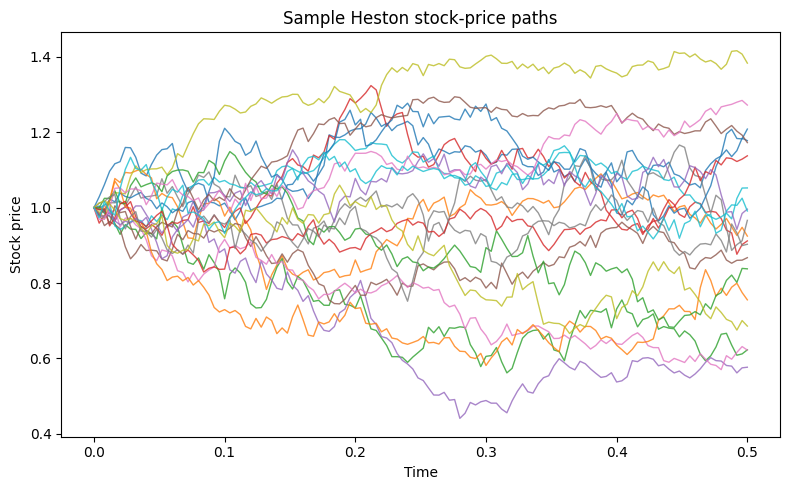

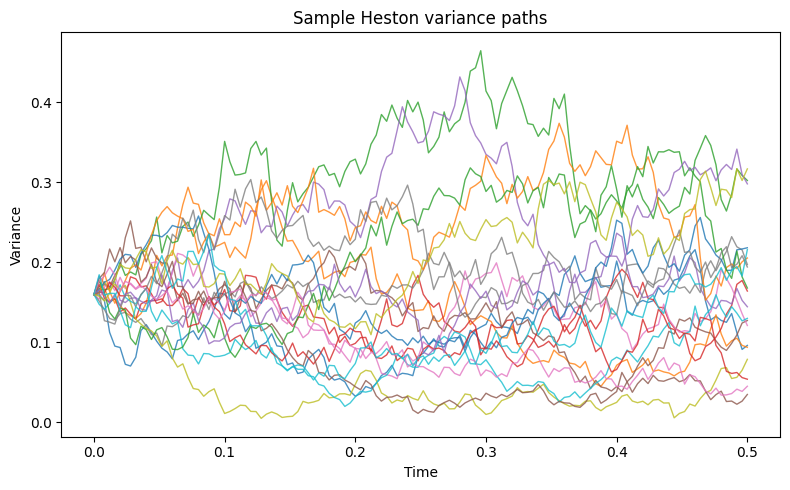

In [8]:

# ============================================================
# Heston parameter table and sample-path diagnostics
# ============================================================

parameter_rows = [
    {"Parameter": r"$S_0$", "Value": S0, "Description": "Initial stock price"},
    {"Parameter": r"$K$", "Value": K_TARGET, "Description": "Target option strike"},
    {"Parameter": r"$T$", "Value": T_TARGET, "Description": "Target option maturity"},
    {"Parameter": r"$r$", "Value": R, "Description": "Risk-free rate"},
    {"Parameter": r"$N$", "Value": N_STEPS, "Description": "Number of rebalancing dates"},
    {"Parameter": r"$v_0$", "Value": V0, "Description": "Initial variance"},
    {"Parameter": r"$\kappa$", "Value": KAPPA, "Description": "Variance mean-reversion speed"},
    {"Parameter": r"$\theta$", "Value": THETA, "Description": "Long-run variance"},
    {"Parameter": r"$\xi$", "Value": XI, "Description": "Volatility of variance"},
    {"Parameter": r"$\rho$", "Value": RHO, "Description": "Spot/variance Brownian correlation"},
    {"Parameter": r"$K_h$", "Value": K_HEDGE, "Description": "Liquid hedging-option strike"},
    {"Parameter": r"$T_h$", "Value": T_HEDGE, "Description": "Liquid hedging-option maturity"},
]

heston_parameter_table = pd.DataFrame(parameter_rows)
heston_parameter_table.to_csv(Path(OUTPUT_DIR) / "heston_parameter_table.csv", index=False)
display(heston_parameter_table)

print("LaTeX parameter table:")
print(heston_parameter_table.to_latex(index=False, escape=False, float_format=lambda x: f"{x:.4f}"))

# Sample-path figures
n_plot = min(20, S_train.shape[0])
idx = torch.linspace(0, S_train.shape[0] - 1, n_plot).long()
times_np = times.detach().cpu().numpy()

plt.figure(figsize=(8, 5))
for i in idx:
    plt.plot(times_np, S_train[i].detach().cpu().numpy(), linewidth=1.0, alpha=0.8)
plt.xlabel("Time")
plt.ylabel("Stock price")
plt.title("Sample Heston stock-price paths")
plt.tight_layout()
plt.savefig(Path(OUTPUT_DIR) / "heston_sample_stock_paths.png", dpi=200)
plt.show()

plt.figure(figsize=(8, 5))
for i in idx:
    plt.plot(times_np, v_train[i].detach().cpu().numpy(), linewidth=1.0, alpha=0.8)
plt.xlabel("Time")
plt.ylabel("Variance")
plt.title("Sample Heston variance paths")
plt.tight_layout()
plt.savefig(Path(OUTPUT_DIR) / "heston_sample_variance_paths.png", dpi=200)
plt.show()


## Observable-volatility ablation

Instantaneous variance `v_t` is **latent** under Heston: it is not observable in a real market. The full-information runs condition the hedge on the true `v_t` (feature `v/theta`). This block builds an **observable** proxy from the stock path alone -- an EWMA of squared log-returns -- and, when `USE_OBSERVABLE_VOL=True`, substitutes it for the true variance in **every** model input and benchmark Greek, so all strategies stay on the same footing.

What stays on true `v`: the simulated paths and the traded option price `C^h` (an observable quote -- you read it, you do not refilter it). What switches to the proxy: the variance the hedging rules *condition on*. Run the notebook once with the flag `False` and once `True`, then compare the result tables to see how much of the stock-and-option edge survives a noisy, lagging, market-observable vol signal.

In [9]:
# ============================================================
# EWMA realized-variance proxy for the observable-vol ablation
# ============================================================

def ewma_realized_variance(S, times, lam=EWMA_LAMBDA, v0=V0):
    """Causal EWMA realized-variance estimate from the observed stock path.
    r_n = log(S_{t_n}/S_{t_{n-1}}) is known at t_n, so v_hat_{t_n} may use it.
    Returns v_hat with the same shape as S; v_hat[:,0] seeded at the prior v0."""
    dt = float(times[1] - times[0])
    logS = torch.log(S.clamp_min(1e-12))
    inst = (logS[:, 1:] - logS[:, :-1]) ** 2 / dt          # per-step variance proxy
    v_hat = torch.empty_like(S)
    v_hat[:, 0] = v0
    for n in range(1, S.shape[1]):
        v_hat[:, n] = lam * v_hat[:, n - 1] + (1.0 - lam) * inst[:, n - 1]
    return v_hat

# keep explicit handles on the true (latent) variance
v_train_true, v_val_true, v_test_true = v_train, v_val, v_test

v_obs_train = ewma_realized_variance(S_train, times)
v_obs_val   = ewma_realized_variance(S_val,   times)
v_obs_test  = ewma_realized_variance(S_test,  times)

# proxy-quality diagnostic on the test set
_vt = v_test_true.reshape(-1); _vh = v_obs_test.reshape(-1)
_corr = float(torch.corrcoef(torch.stack([_vt, _vh]))[0, 1])
_rmse = float(((_vh - _vt) ** 2).mean().sqrt())
print(f"EWMA realized-variance proxy (lambda={EWMA_LAMBDA}):")
print(f"  corr(v_hat, v_true) = {_corr:.3f} | RMSE = {_rmse:.4f} | mean v_true = {float(_vt.mean()):.4f}")

# When the ablation is on, every model input and benchmark Greek uses the proxy.
# (C_train/C_val/C_test are NOT touched: the traded option price stays an observable
#  true-v quote; the hedger conditions on v_hat but is marked to market at the real price.)
if USE_OBSERVABLE_VOL:
    v_train, v_val, v_test = v_obs_train, v_obs_val, v_obs_test
    print("  MODE: OBSERVABLE volatility -- models and benchmarks condition on v_hat.")
else:
    print("  MODE: FULL-INFORMATION volatility -- models condition on true v_t (default).")


EWMA realized-variance proxy (lambda=0.94):
  corr(v_hat, v_true) = 0.778 | RMSE = 0.0588 | mean v_true = 0.1599
  MODE: FULL-INFORMATION volatility -- models condition on true v_t (default).


In [10]:

# ============================================================
# Feature construction
# ============================================================

def stock_only_features(S, v, times):
    """
    Stock-only Heston hedge features:
        log(S/K_target),
        tau_target/T_target,
        v/theta
    Shape: [B, N_STEPS, 3]
    """
    B = S.shape[0]
    S_n = S[:, :-1]
    v_n = v[:, :-1]
    tau_target = (T_TARGET - times[:-1]).view(1, -1).expand(B, -1)

    return torch.stack([
        torch.log(torch.clamp(S_n, min=1e-12) / K_TARGET),
        tau_target / T_TARGET,
        v_n / THETA,
    ], dim=-1)


def stock_option_features(S, v, C_h, times):
    """
    Stock + liquid-option Heston hedge features:
        log(S/K_target),
        tau_target/T_target,
        v/theta,
        log(S/K_hedge),
        tau_hedge/T_hedge,
        C_h/S

    Shape: [B, N_STEPS, 6]
    """
    B = S.shape[0]
    S_n = S[:, :-1]
    v_n = v[:, :-1]
    C_n = C_h[:, :-1]

    tau_target = (T_TARGET - times[:-1]).view(1, -1).expand(B, -1)
    tau_hedge = (T_HEDGE - times[:-1]).view(1, -1).expand(B, -1)

    return torch.stack([
        torch.log(torch.clamp(S_n, min=1e-12) / K_TARGET),
        tau_target / T_TARGET,
        v_n / THETA,
        torch.log(torch.clamp(S_n, min=1e-12) / K_HEDGE),
        tau_hedge / T_HEDGE,
        C_n / torch.clamp(S_n, min=1e-12),
    ], dim=-1)


In [11]:

# ============================================================
# Neural hedge models
# ============================================================

class StockOnlyHestonNN(nn.Module):
    """
    Stock-only neural hedge under Heston dynamics.
    Output is bounded to [0,1] as a natural call-delta-like position.
    """
    def __init__(self, hidden_width=64, hidden_depth=3):
        super().__init__()
        layers = []
        in_dim = 3
        for _ in range(hidden_depth):
            layers.append(nn.Linear(in_dim, hidden_width))
            layers.append(nn.Tanh())
            in_dim = hidden_width
        layers.append(nn.Linear(hidden_width, 1))
        self.net = nn.Sequential(*layers)
        self.premium = nn.Parameter(torch.tensor(target_premium_mc, dtype=torch.float32))

    def forward(self, x):
        B, N, D = x.shape
        raw = self.net(x.reshape(B * N, D)).reshape(B, N)
        delta = torch.sigmoid(raw)
        return delta


class StockOptionHestonNN(nn.Module):
    """
    Stock + liquid-option neural hedge under Heston dynamics.
    Outputs:
        delta_n: stock position
        eta_n: liquid-option position

    Tanh-scaled outputs are used because multi-instrument hedge positions
    need not lie in [0,1].
    """
    def __init__(self, hidden_width=64, hidden_depth=3, delta_scale=5.0, eta_scale=5.0):
        super().__init__()
        self.delta_scale = delta_scale
        self.eta_scale = eta_scale

        layers = []
        in_dim = 6
        for _ in range(hidden_depth):
            layers.append(nn.Linear(in_dim, hidden_width))
            layers.append(nn.Tanh())
            in_dim = hidden_width
        layers.append(nn.Linear(hidden_width, 2))
        self.net = nn.Sequential(*layers)
        self.premium = nn.Parameter(torch.tensor(target_premium_mc, dtype=torch.float32))

    def forward(self, x):
        B, N, D = x.shape
        raw = self.net(x.reshape(B * N, D)).reshape(B, N, 2)
        delta = self.delta_scale * torch.tanh(raw[..., 0])
        eta = self.eta_scale * torch.tanh(raw[..., 1])
        return delta, eta


In [12]:

# ============================================================
# Hedge error functions
# ============================================================

def hedge_error_stock_only(model, S, v, C_h, payoff, times):
    x = stock_only_features(S, v, times)
    delta = model(x)
    eta = torch.zeros_like(delta)

    dS = S[:, 1:] - S[:, :-1]
    gains = torch.sum(delta * dS, dim=1)
    he = model.premium + gains - payoff

    positions = {"delta": delta, "eta": eta}
    return he, positions


def hedge_error_stock_option(model, S, v, C_h, payoff, times):
    x = stock_option_features(S, v, C_h, times)
    delta, eta = model(x)

    dS = S[:, 1:] - S[:, :-1]
    dC = C_h[:, 1:] - C_h[:, :-1]

    gains = torch.sum(delta * dS + eta * dC, dim=1)
    he = model.premium + gains - payoff

    positions = {"delta": delta, "eta": eta}
    return he, positions


def position_turnover(pos):
    prev = torch.cat([torch.zeros(pos.shape[0], 1, device=pos.device), pos[:, :-1]], dim=1)
    return torch.sum(torch.abs(pos - prev), dim=1)


In [13]:

# ============================================================
# Training
# ============================================================

def train_model(model, kind, S_train, v_train, C_train, y_train, S_val, v_val, C_val, y_val, times):
    """
    kind: 'stock' or 'stock_option'
    """
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

    best_val = float("inf")
    best_state = None
    bad_epochs = 0
    history = []

    n = S_train.shape[0]

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        perm = torch.randperm(n, device=device)
        batch_losses = []

        for start in range(0, n, BATCH_SIZE):
            idx = perm[start:start + BATCH_SIZE]
            optimizer.zero_grad()

            if kind == "stock":
                he, _ = hedge_error_stock_only(model, S_train[idx], v_train[idx], C_train[idx], y_train[idx], times)
            else:
                he, _ = hedge_error_stock_option(model, S_train[idx], v_train[idx], C_train[idx], y_train[idx], times)

            loss = torch.mean(he ** 2)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()
            batch_losses.append(float(loss.detach().cpu()))

        model.eval()
        with torch.no_grad():
            if kind == "stock":
                he_val, _ = hedge_error_stock_only(model, S_val, v_val, C_val, y_val, times)
            else:
                he_val, _ = hedge_error_stock_option(model, S_val, v_val, C_val, y_val, times)
            val_loss = float(torch.mean(he_val ** 2).detach().cpu())

        train_loss = float(np.mean(batch_losses))
        premium = float(model.premium.detach().cpu())
        history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss, "premium": premium})

        if epoch == 1 or epoch % 10 == 0:
            print(f"{kind:12s} epoch {epoch:4d} | train {train_loss:.8e} | val {val_loss:.8e} | premium {premium:.6f}")

        if val_loss < best_val - 1e-10:
            best_val = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1

        if bad_epochs >= PATIENCE:
            print(f"Early stopping {kind} at epoch {epoch}; best val {best_val:.8e}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, pd.DataFrame(history)


In [14]:

# ============================================================
# Proxy analytic benchmark strategies
# ============================================================

@torch.no_grad()
def proxy_stock_delta_positions(S, v, times):
    """
    Black--Scholes proxy stock delta using instantaneous volatility sqrt(v_t).
    """
    B = S.shape[0]
    S_n = S[:, :-1]
    vol_n = torch.sqrt(torch.clamp(v[:, :-1], min=1e-10))
    tau_target = (T_TARGET - times[:-1]).view(1, -1).expand(B, -1)

    delta = bs_delta(S_n, K_TARGET, tau_target, vol_n)
    eta = torch.zeros_like(delta)
    return delta, eta


@torch.no_grad()
def proxy_delta_vega_positions(S, v, times):
    """Heston delta--vega benchmark via COS Greeks (was a BS-proxy Greek match).
    Matches dC/dv exposure with the liquid option, residual delta with the stock.
    Positions clipped to [-clip, clip] for numerical stability."""
    return heston_delta_vega_positions(
        S, v, times, HESTON_PARAMS,
        K_TARGET, T_TARGET, K_HEDGE, T_HEDGE,
        delta_clip=DELTA_CLIP, eta_clip=ETA_CLIP,
    )


@torch.no_grad()
def evaluate_given_positions(name, premium, delta, eta, S, C_h, payoff):
    dS = S[:, 1:] - S[:, :-1]
    dC = C_h[:, 1:] - C_h[:, :-1]
    he = premium + torch.sum(delta * dS + eta * dC, dim=1) - payoff
    return summarize_strategy(name, premium, he, {"delta": delta, "eta": eta})


def summarize_strategy(name, premium, he, positions):
    he_np = he.detach().cpu().numpy()
    loss = -he_np

    delta = positions["delta"]
    eta = positions["eta"]

    stock_turn = position_turnover(delta).detach().cpu().numpy()
    option_turn = position_turnover(eta).detach().cpu().numpy()

    def cvar_upper(x, alpha):
        q = np.quantile(x, alpha)
        return x[x >= q].mean()

    return {
        "Strategy": name,
        "Premium": float(premium),
        "RMSE": float(np.sqrt(np.mean(he_np ** 2))),
        "Mean HE": float(np.mean(he_np)),
        "Std HE": float(np.std(he_np)),
        "HE q01": float(np.quantile(he_np, 0.01)),
        "HE q05": float(np.quantile(he_np, 0.05)),
        "Loss VaR95": float(np.quantile(loss, 0.95)),
        "Loss CVaR95": float(cvar_upper(loss, 0.95)),
        "Loss VaR99": float(np.quantile(loss, 0.99)),
        "Loss CVaR99": float(cvar_upper(loss, 0.99)),
        "Mean abs delta": float(torch.mean(torch.abs(delta)).detach().cpu()),
        "Mean abs eta": float(torch.mean(torch.abs(eta)).detach().cpu()),
        "Mean stock turnover": float(np.mean(stock_turn)),
        "Mean option turnover": float(np.mean(option_turn)),
        "Median stock turnover": float(np.median(stock_turn)),
        "Median option turnover": float(np.median(option_turn)),
    }


In [15]:

# ============================================================
# Train models
# ============================================================

stock_model = StockOnlyHestonNN(HIDDEN_WIDTH, HIDDEN_DEPTH)
stock_option_model = StockOptionHestonNN(HIDDEN_WIDTH, HIDDEN_DEPTH, DELTA_SCALE, ETA_SCALE)

print("Training stock-only Heston neural hedge...")
stock_model, hist_stock = train_model(
    stock_model,
    "stock",
    S_train, v_train, C_train, payoff_train,
    S_val, v_val, C_val, payoff_val,
    times,
)

print("\nTraining stock + option Heston neural hedge...")
stock_option_model, hist_stock_option = train_model(
    stock_option_model,
    "stock_option",
    S_train, v_train, C_train, payoff_train,
    S_val, v_val, C_val, payoff_val,
    times,
)

hist_stock.to_csv(Path(OUTPUT_DIR) / "stock_only_heston_training_history.csv", index=False)
hist_stock_option.to_csv(Path(OUTPUT_DIR) / "stock_option_heston_training_history.csv", index=False)


Training stock-only Heston neural hedge...


stock        epoch    1 | train 4.81163019e-03 | val 2.76405201e-03 | premium 0.165111


stock        epoch   10 | train 4.45102084e-04 | val 4.38090618e-04 | premium 0.165238


stock        epoch   20 | train 3.39330593e-04 | val 3.40326922e-04 | premium 0.165097


stock        epoch   30 | train 3.24912859e-04 | val 3.26094188e-04 | premium 0.165247


...

stock_option epoch  110 | train 1.03583758e-04 | val 8.92091703e-05 | premium 0.164837


stock_option epoch  120 | train 8.19793632e-05 | val 9.90763074e-05 | premium 0.164846


stock_option epoch  130 | train 6.20364620e-05 | val 6.18424529e-05 | premium 0.164630


stock_option epoch  140 | train 5.89345937e-05 | val 5.77915380e-05 | premium 0.164862


stock_option epoch  150 | train 5.80472503e-05 | val 6.30144132e-05 | premium 0.164917



## Superseded fixed-premium results below

The next original evaluation/table/plot cells are kept for reproducibility, but their fixed-premium results should **not** be used as the headline dissertation results.

The canonical headline results are produced later in the technical revision block using symmetric fair-premium evaluation:

```text
heston_revised_results_fair_premium.csv
```

Use the original cells only as historical/prototype diagnostics.


In [16]:

# ============================================================
# Evaluate on common test set
# ============================================================

results = []

with torch.no_grad():
    zero = torch.zeros(N_TEST, N_STEPS, device=device)

    # No hedge
    results.append(evaluate_given_positions(
        "No hedge",
        target_premium_mc,
        zero,
        zero,
        S_test,
        C_test,
        payoff_test,
    ))

    # Proxy stock delta
    proxy_delta, proxy_eta_zero = proxy_stock_delta_positions(S_test, v_test, times)
    results.append(evaluate_given_positions(
        "BS proxy stock delta",
        target_premium_mc,
        proxy_delta,
        proxy_eta_zero,
        S_test,
        C_test,
        payoff_test,
    ))

    # Proxy delta-vega hedge
    dv_delta, dv_eta = proxy_delta_vega_positions(S_test, v_test, times)
    results.append(evaluate_given_positions(
        f"Heston delta-vega hedge (eta clipped {ETA_CLIP:g})",
        target_premium_mc,
        dv_delta,
        dv_eta,
        S_test,
        C_test,
        payoff_test,
    ))

    # Stock-only neural hedge
    he_stock, pos_stock = hedge_error_stock_only(stock_model, S_test, v_test, C_test, payoff_test, times)
    results.append(summarize_strategy(
        "Stock-only NN under Heston",
        float(stock_model.premium.detach().cpu()),
        he_stock,
        pos_stock,
    ))

    # Stock + option neural hedge
    he_stock_option, pos_stock_option = hedge_error_stock_option(stock_option_model, S_test, v_test, C_test, payoff_test, times)
    results.append(summarize_strategy(
        "Stock + option NN under Heston",
        float(stock_option_model.premium.detach().cpu()),
        he_stock_option,
        pos_stock_option,
    ))

results_df = pd.DataFrame(results)
results_df.to_csv(RESULTS_CSV, index=False)
results_df.to_csv(Path(OUTPUT_DIR) / RESULTS_CSV, index=False)

pd.set_option("display.max_columns", 40)
display(results_df)
print(f"Saved results to {RESULTS_CSV} and {Path(OUTPUT_DIR) / RESULTS_CSV}")


,Strategy,Premium,RMSE,Mean HE,Std HE,HE q01,HE q05,Loss VaR95,Loss CVaR95,Loss VaR99,Loss CVaR99,Mean abs delta,Mean abs eta,Mean stock turnover,Mean option turnover,Median stock turnover,Median option turnover
0,No hedge,0.165414,0.190062,0.000625,0.190061,-0.566132,-0.374096,0.374096,0.492334,0.566132,0.672720,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,BS proxy stock delta,0.165414,0.020006,0.000579,0.019997,-0.052104,-0.035601,0.035601,0.045782,0.052104,0.060295,0.682122,0.000000,3.894743,0.000000,3.830949,0.000000
2,Heston delta-vega hedge (eta clipped 5),0.165414,0.014792,0.000552,0.014782,-0.037633,-0.024444,0.024444,0.032698,0.037633,0.045863,0.386796,0.603444,5.392436,7.131248,4.812611,5.589368
3,Stock-only NN under Heston,0.164819,0.017325,-0.000030,0.017325,-0.045952,-0.029933,0.029933,0.039961,0.045952,0.055670,0.646223,0.000000,3.820175,0.000000,3.744974,0.000000
4,Stock + option NN under Heston,0.164796,0.007427,-0.000099,0.007426,-0.019950,-0.011495,0.011495,0.016723,0.019950,0.024718,0.368615,0.599272,3.122542,4.691251,2.989698,4.678315


Saved results to heston_delta_vega_results.csv and heston_delta_vega_outputs/heston_delta_vega_results.csv


In [17]:

# ============================================================
# Improvement summary
# ============================================================

def pct_improvement(old, new):
    return 100.0 * (old - new) / old

stock_nn = results_df.loc[results_df["Strategy"] == "Stock-only NN under Heston"].iloc[0]
stock_option_nn = results_df.loc[results_df["Strategy"] == "Stock + option NN under Heston"].iloc[0]
proxy_stock = results_df.loc[results_df["Strategy"] == "BS proxy stock delta"].iloc[0]
proxy_dv = results_df[results_df["Strategy"].str.startswith("Heston delta-vega")].iloc[0]

summary = pd.DataFrame([
    {
        "Comparison": "Stock + option NN vs stock-only NN",
        "RMSE improvement (%)": pct_improvement(stock_nn["RMSE"], stock_option_nn["RMSE"]),
        "Loss CVaR95 improvement (%)": pct_improvement(stock_nn["Loss CVaR95"], stock_option_nn["Loss CVaR95"]),
    },
    {
        "Comparison": "Stock + option NN vs BS proxy stock delta",
        "RMSE improvement (%)": pct_improvement(proxy_stock["RMSE"], stock_option_nn["RMSE"]),
        "Loss CVaR95 improvement (%)": pct_improvement(proxy_stock["Loss CVaR95"], stock_option_nn["Loss CVaR95"]),
    },
    {
        "Comparison": "Stock + option NN vs Heston delta-vega",
        "RMSE improvement (%)": pct_improvement(proxy_dv["RMSE"], stock_option_nn["RMSE"]),
        "Loss CVaR95 improvement (%)": pct_improvement(proxy_dv["Loss CVaR95"], stock_option_nn["Loss CVaR95"]),
    },
])
display(summary)
summary.to_csv(Path(OUTPUT_DIR) / "heston_delta_vega_improvement_summary.csv", index=False)


,Comparison,RMSE improvement (%),Loss CVaR95 improvement (%)
0,Stock + option NN vs stock-only NN,57.131207,58.151961
1,Stock + option NN vs BS proxy stock delta,62.876298,63.472655
2,Stock + option NN vs Heston delta-vega,49.791137,48.857492


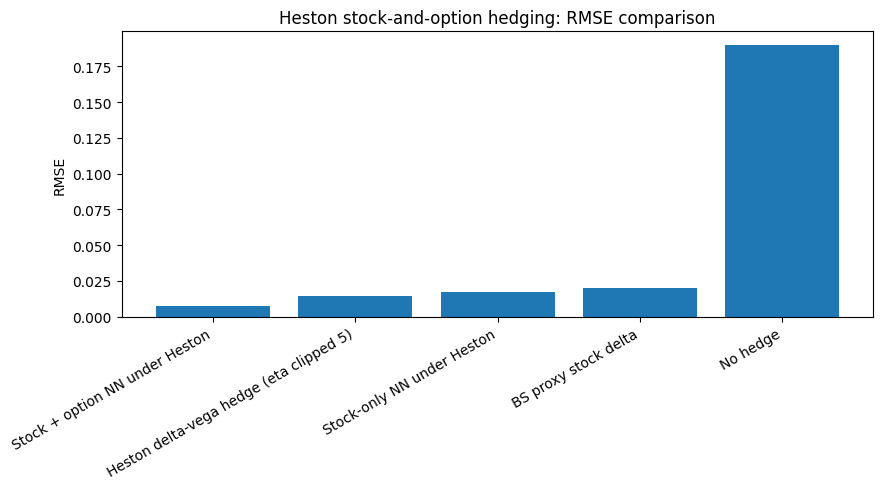

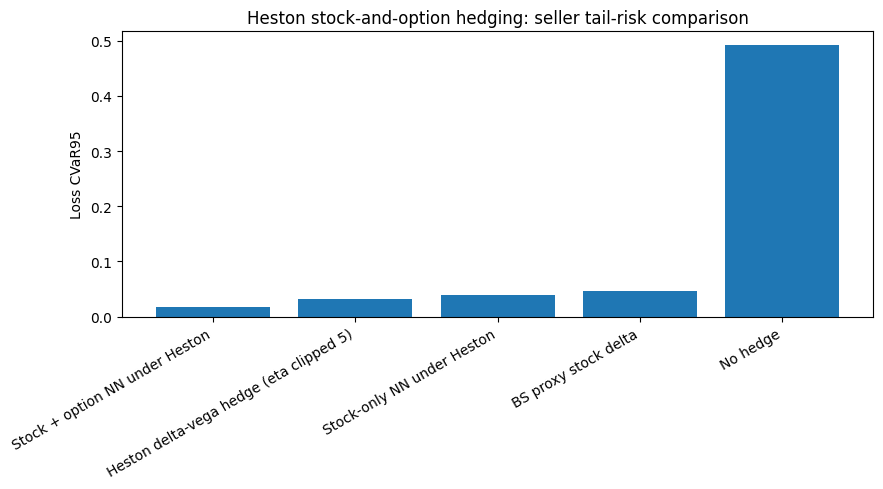

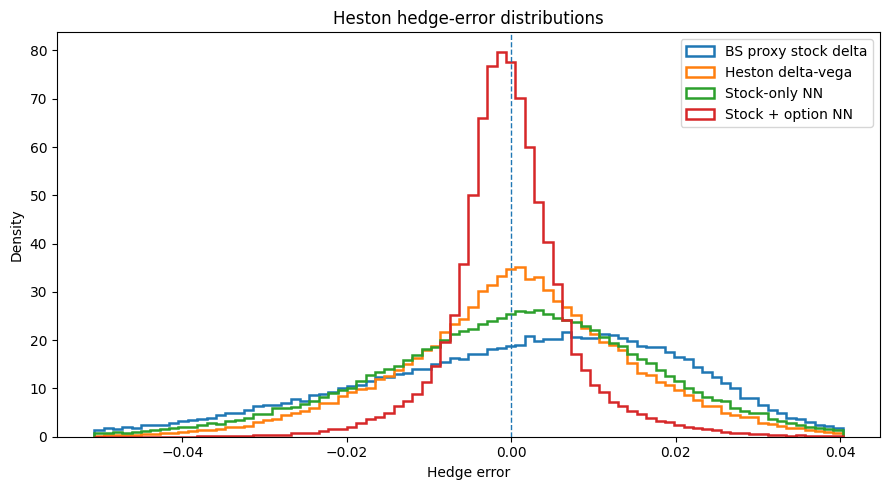

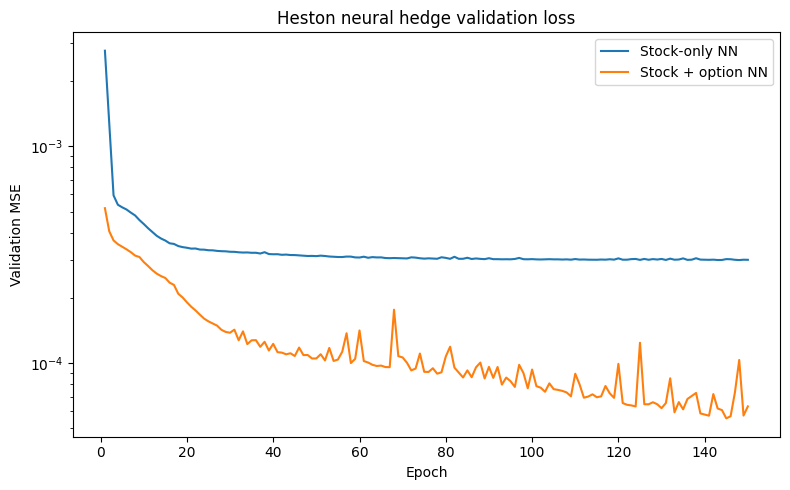

In [18]:

# ============================================================
# Plots
# ============================================================

# RMSE bar plot
plot_df = results_df.sort_values("RMSE")
plt.figure(figsize=(9, 5))
plt.bar(plot_df["Strategy"], plot_df["RMSE"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("RMSE")
plt.title("Heston stock-and-option hedging: RMSE comparison")
plt.tight_layout()
plt.savefig(Path(OUTPUT_DIR) / "heston_delta_vega_rmse_bar.png", dpi=200)
plt.show()

# Loss CVaR95 bar plot
plot_df = results_df.sort_values("Loss CVaR95")
plt.figure(figsize=(9, 5))
plt.bar(plot_df["Strategy"], plot_df["Loss CVaR95"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("Loss CVaR95")
plt.title("Heston stock-and-option hedging: seller tail-risk comparison")
plt.tight_layout()
plt.savefig(Path(OUTPUT_DIR) / "heston_delta_vega_cvar95_bar.png", dpi=200)
plt.show()

# Hedge-error distributions for key strategies
with torch.no_grad():
    he_proxy_stock = target_premium_mc + torch.sum(proxy_delta * (S_test[:, 1:] - S_test[:, :-1]), dim=1) - payoff_test
    he_proxy_dv = target_premium_mc + torch.sum(
        dv_delta * (S_test[:, 1:] - S_test[:, :-1]) + dv_eta * (C_test[:, 1:] - C_test[:, :-1]),
        dim=1
    ) - payoff_test
    he_stock, _ = hedge_error_stock_only(stock_model, S_test, v_test, C_test, payoff_test, times)
    he_stock_option, _ = hedge_error_stock_option(stock_option_model, S_test, v_test, C_test, payoff_test, times)

he_dict = {
    "BS proxy stock delta": he_proxy_stock.detach().cpu().numpy(),
    "Heston delta-vega": he_proxy_dv.detach().cpu().numpy(),
    "Stock-only NN": he_stock.detach().cpu().numpy(),
    "Stock + option NN": he_stock_option.detach().cpu().numpy(),
}

all_he = np.concatenate(list(he_dict.values()))
lo, hi = np.quantile(all_he, [0.005, 0.995])

plt.figure(figsize=(9, 5))
for name, he in he_dict.items():
    plt.hist(he, bins=80, range=(lo, hi), density=True, histtype="step", linewidth=1.8, label=name)
plt.axvline(0.0, linestyle="--", linewidth=1.0)
plt.xlabel("Hedge error")
plt.ylabel("Density")
plt.title("Heston hedge-error distributions")
plt.legend()
plt.tight_layout()
plt.savefig(Path(OUTPUT_DIR) / "heston_delta_vega_hedge_error_histograms.png", dpi=200)
plt.show()

# Validation loss
plt.figure(figsize=(8, 5))
plt.plot(hist_stock["epoch"], hist_stock["val_loss"], label="Stock-only NN")
plt.plot(hist_stock_option["epoch"], hist_stock_option["val_loss"], label="Stock + option NN")
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Validation MSE")
plt.title("Heston neural hedge validation loss")
plt.legend()
plt.tight_layout()
plt.savefig(Path(OUTPUT_DIR) / "heston_delta_vega_validation_loss.png", dpi=200)
plt.show()


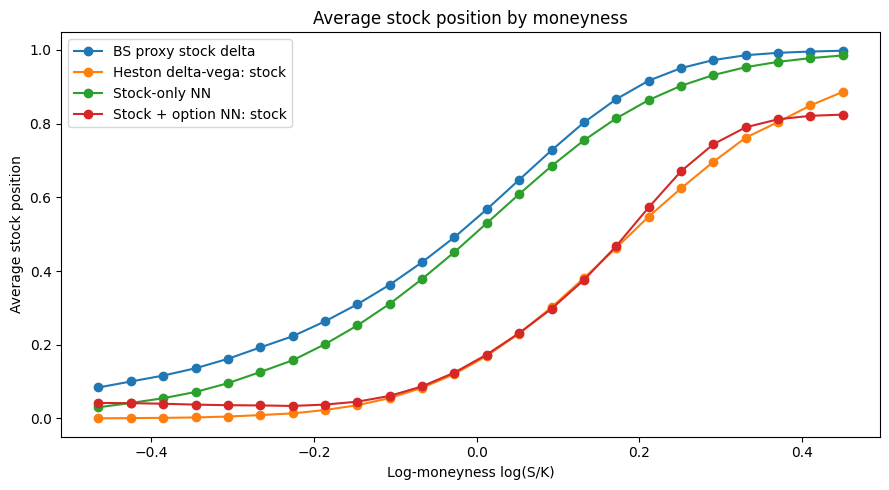

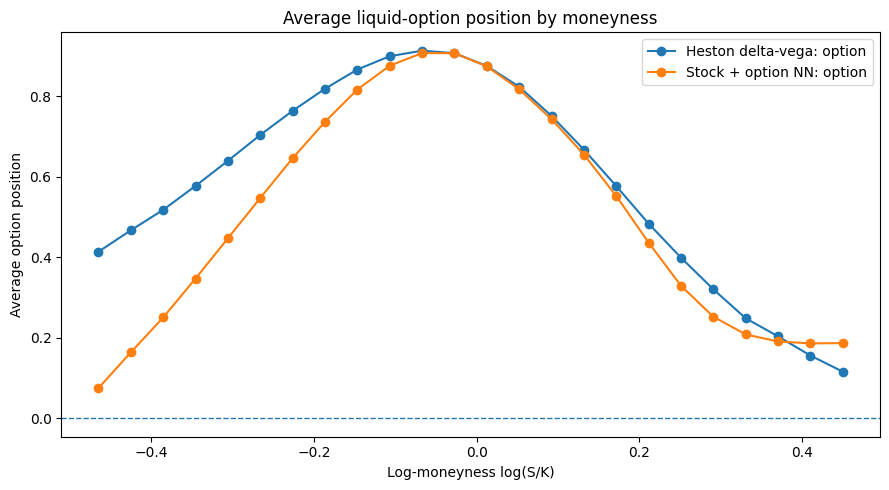

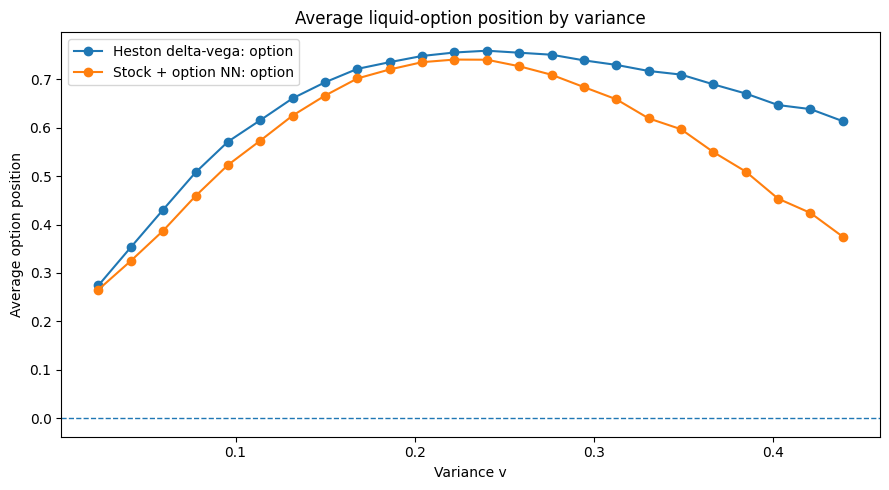

,log_moneyness_mid,proxy_stock_delta,proxy_dv_delta,proxy_dv_eta,stock_nn_delta,stock_option_nn_delta,stock_option_nn_eta
0,-0.464604,0.084101,0.000311,0.413808,0.030325,0.042048,0.075087
1,-0.424842,0.100325,0.000944,0.466905,0.042081,0.041544,0.163923
2,-0.385081,0.116349,0.001628,0.517822,0.054858,0.039926,0.250534
3,-0.345319,0.136219,0.002723,0.577226,0.071912,0.037513,0.347204
4,-0.305558,0.161810,0.005151,0.639466,0.095660,0.035971,0.447182


In [19]:

# ============================================================
# Position diagnostics by moneyness and variance
# ============================================================

@torch.no_grad()
def binned_positions_by_variable(var_np, positions, time_index, n_bins=25):
    delta = positions["delta"][:, time_index].detach().cpu().numpy()
    eta = positions["eta"][:, time_index].detach().cpu().numpy()

    bins = np.linspace(np.quantile(var_np, 0.01), np.quantile(var_np, 0.99), n_bins)
    mids = 0.5 * (bins[:-1] + bins[1:])
    avg_delta, avg_eta = [], []

    for a, b in zip(bins[:-1], bins[1:]):
        mask = (var_np >= a) & (var_np < b)
        if mask.sum() == 0:
            avg_delta.append(np.nan)
            avg_eta.append(np.nan)
        else:
            avg_delta.append(np.mean(delta[mask]))
            avg_eta.append(np.mean(eta[mask]))

    return mids, np.array(avg_delta), np.array(avg_eta)


mid_index = N_STEPS // 2

with torch.no_grad():
    _, pos_stock = hedge_error_stock_only(stock_model, S_test, v_test, C_test, payoff_test, times)
    _, pos_stock_option = hedge_error_stock_option(stock_option_model, S_test, v_test, C_test, payoff_test, times)

log_m = torch.log(S_test[:, mid_index] / K_TARGET).detach().cpu().numpy()
variance_mid = v_test[:, mid_index].detach().cpu().numpy()

m_mids, stock_delta_m, _ = binned_positions_by_variable(log_m, pos_stock, mid_index)
_, so_delta_m, so_eta_m = binned_positions_by_variable(log_m, pos_stock_option, mid_index)
_, proxy_delta_m, _ = binned_positions_by_variable(log_m, {"delta": proxy_delta, "eta": proxy_eta_zero}, mid_index)
_, dv_delta_m, dv_eta_m = binned_positions_by_variable(log_m, {"delta": dv_delta, "eta": dv_eta}, mid_index)

# Stock position by moneyness
plt.figure(figsize=(9, 5))
plt.plot(m_mids, proxy_delta_m, marker="o", label="BS proxy stock delta")
plt.plot(m_mids, dv_delta_m, marker="o", label="Heston delta-vega: stock")
plt.plot(m_mids, stock_delta_m, marker="o", label="Stock-only NN")
plt.plot(m_mids, so_delta_m, marker="o", label="Stock + option NN: stock")
plt.xlabel("Log-moneyness log(S/K)")
plt.ylabel("Average stock position")
plt.title("Average stock position by moneyness")
plt.legend()
plt.tight_layout()
plt.savefig(Path(OUTPUT_DIR) / "heston_stock_position_by_moneyness.png", dpi=200)
plt.show()

# Option position by moneyness
plt.figure(figsize=(9, 5))
plt.plot(m_mids, dv_eta_m, marker="o", label="Heston delta-vega: option")
plt.plot(m_mids, so_eta_m, marker="o", label="Stock + option NN: option")
plt.axhline(0.0, linestyle="--", linewidth=1.0)
plt.xlabel("Log-moneyness log(S/K)")
plt.ylabel("Average option position")
plt.title("Average liquid-option position by moneyness")
plt.legend()
plt.tight_layout()
plt.savefig(Path(OUTPUT_DIR) / "heston_option_position_by_moneyness.png", dpi=200)
plt.show()

# Option position by variance
v_mids, _, so_eta_v = binned_positions_by_variable(variance_mid, pos_stock_option, mid_index)
_, _, dv_eta_v = binned_positions_by_variable(variance_mid, {"delta": dv_delta, "eta": dv_eta}, mid_index)

plt.figure(figsize=(9, 5))
plt.plot(v_mids, dv_eta_v, marker="o", label="Heston delta-vega: option")
plt.plot(v_mids, so_eta_v, marker="o", label="Stock + option NN: option")
plt.axhline(0.0, linestyle="--", linewidth=1.0)
plt.xlabel("Variance v")
plt.ylabel("Average option position")
plt.title("Average liquid-option position by variance")
plt.legend()
plt.tight_layout()
plt.savefig(Path(OUTPUT_DIR) / "heston_option_position_by_variance.png", dpi=200)
plt.show()

diagnostic_df = pd.DataFrame({
    "log_moneyness_mid": m_mids,
    "proxy_stock_delta": proxy_delta_m,
    "proxy_dv_delta": dv_delta_m,
    "proxy_dv_eta": dv_eta_m,
    "stock_nn_delta": stock_delta_m,
    "stock_option_nn_delta": so_delta_m,
    "stock_option_nn_eta": so_eta_m,
})
diagnostic_df.to_csv(Path(OUTPUT_DIR) / "heston_positions_by_moneyness.csv", index=False)
display(diagnostic_df.head())


In [20]:

# ============================================================
# LaTeX table helper
# ============================================================

latex_cols = [
    "Strategy",
    "Premium",
    "RMSE",
    "Loss CVaR95",
    "Loss CVaR99",
    "Mean abs delta",
    "Mean abs eta",
    "Mean stock turnover",
    "Mean option turnover",
]

latex_df = results_df[latex_cols].copy()
print(latex_df.to_latex(index=False, float_format=lambda x: f"{x:.6f}", escape=False))


\begin{tabular}{lrrrrrrrr}
\toprule
Strategy & Premium & RMSE & Loss CVaR95 & Loss CVaR99 & Mean abs delta & Mean abs eta & Mean stock turnover & Mean option turnover \\
\midrule
No hedge & 0.165414 & 0.190062 & 0.492334 & 0.672720 & 0.000000 & 0.000000 & 0.000000 & 0.000000 \\
BS proxy stock delta & 0.165414 & 0.020006 & 0.045782 & 0.060295 & 0.682122 & 0.000000 & 3.894743 & 0.000000 \\
Heston delta-vega hedge (eta clipped 5) & 0.165414 & 0.014792 & 0.032698 & 0.045863 & 0.386796 & 0.603444 & 5.392436 & 7.131248 \\
Stock-only NN under Heston & 0.164819 & 0.017325 & 0.039961 & 0.055670 & 0.646223 & 0.000000 & 3.820175 & 0.000000 \\
Stock + option NN under Heston & 0.164796 & 0.007427 & 0.016723 & 0.024718 & 0.368615 & 0.599272 & 3.122542 & 4.691251 \\
\bottomrule
\end{tabular}




## Report wording guidance

Use cautious wording.

Good wording:

> We extend the hedging problem to a stochastic-volatility setting by simulating Heston dynamics and allowing the neural strategy to trade both the underlying stock and a liquid option proxy. In contrast to the Black--Scholes setting, the second option is not merely a redundant instrument: it provides exposure to volatility risk and therefore plays the role of a vega-hedging asset.

Important caveat:

> The liquid option price is approximated using a Black--Scholes proxy with instantaneous volatility \(\sqrt{v_t}\), rather than exact Heston Fourier pricing. The experiment should therefore be interpreted as a practical stock-and-option hedging proxy under stochastic volatility, not as an exact Heston calibration exercise.

Avoid saying:

> The neural hedge proves that the option is exactly vega hedging.

Safer:

> The learned option position is consistent with the use of a liquid option to manage volatility exposure under stochastic volatility.



## Report output manifest

After running the notebook, the following files should be available for the report.

Recommended main-table files:

- `heston_delta_vega_results.csv`
- `heston_delta_vega_outputs/heston_delta_vega_results.csv`
- `heston_delta_vega_outputs/heston_delta_vega_improvement_summary.csv`
- `heston_delta_vega_outputs/heston_parameter_table.csv`

Recommended main-report figures:

- `heston_delta_vega_outputs/heston_sample_stock_paths.png`
- `heston_delta_vega_outputs/heston_sample_variance_paths.png`
- `heston_delta_vega_outputs/heston_delta_vega_rmse_bar.png`
- `heston_delta_vega_outputs/heston_delta_vega_cvar95_bar.png`
- `heston_delta_vega_outputs/heston_option_position_by_variance.png`

Optional supporting/appendix figures:

- `heston_delta_vega_outputs/heston_delta_vega_hedge_error_histograms.png`
- `heston_delta_vega_outputs/heston_stock_position_by_moneyness.png`
- `heston_delta_vega_outputs/heston_option_position_by_moneyness.png`
- `heston_delta_vega_outputs/heston_delta_vega_validation_loss.png`


In [21]:

# ============================================================
# Report output manifest
# ============================================================

manifest = pd.DataFrame([
    {"File": "heston_delta_vega_results.csv", "Use": "Main results table"},
    {"File": str(Path(OUTPUT_DIR) / "heston_delta_vega_results.csv"), "Use": "Main results table copy"},
    {"File": str(Path(OUTPUT_DIR) / "heston_delta_vega_improvement_summary.csv"), "Use": "Percentage improvement summary"},
    {"File": str(Path(OUTPUT_DIR) / "heston_parameter_table.csv"), "Use": "Heston parameter table"},
    {"File": str(Path(OUTPUT_DIR) / "heston_sample_stock_paths.png"), "Use": "Show Heston stock dynamics"},
    {"File": str(Path(OUTPUT_DIR) / "heston_sample_variance_paths.png"), "Use": "Show stochastic variance dynamics"},
    {"File": str(Path(OUTPUT_DIR) / "heston_delta_vega_rmse_bar.png"), "Use": "Main RMSE comparison"},
    {"File": str(Path(OUTPUT_DIR) / "heston_delta_vega_cvar95_bar.png"), "Use": "Main seller-tail-risk comparison"},
    {"File": str(Path(OUTPUT_DIR) / "heston_option_position_by_variance.png"), "Use": "Interpretation of liquid-option/vega exposure"},
    {"File": str(Path(OUTPUT_DIR) / "heston_delta_vega_hedge_error_histograms.png"), "Use": "Optional hedge-error distribution"},
    {"File": str(Path(OUTPUT_DIR) / "heston_stock_position_by_moneyness.png"), "Use": "Optional stock-position diagnostic"},
    {"File": str(Path(OUTPUT_DIR) / "heston_option_position_by_moneyness.png"), "Use": "Optional option-position diagnostic"},
    {"File": str(Path(OUTPUT_DIR) / "heston_delta_vega_validation_loss.png"), "Use": "Optional training diagnostic"},
])

manifest.to_csv(Path(OUTPUT_DIR) / "heston_report_output_manifest.csv", index=False)
display(manifest)


,File,Use
0,heston_delta_vega_results.csv,Main results table
1,heston_delta_vega_outputs/heston_delta_vega_re...,Main results table copy
2,heston_delta_vega_outputs/heston_delta_vega_im...,Percentage improvement summary
3,heston_delta_vega_outputs/heston_parameter_tab...,Heston parameter table
4,heston_delta_vega_outputs/heston_sample_stock_...,Show Heston stock dynamics
5,heston_delta_vega_outputs/heston_sample_varian...,Show stochastic variance dynamics
6,heston_delta_vega_outputs/heston_delta_vega_rm...,Main RMSE comparison
7,heston_delta_vega_outputs/heston_delta_vega_cv...,Main seller-tail-risk comparison
8,heston_delta_vega_outputs/heston_option_positi...,Interpretation of liquid-option/vega exposure
9,heston_delta_vega_outputs/heston_delta_vega_he...,Optional hedge-error distribution



# Technical revision cells

These cells respond to the independent review of the Heston stock-and-option extension.

They add:

1. proxy option drift diagnostics;
2. a stock-only tanh-output NN to remove the sigmoid-vs-tanh output confound;
3. symmetric mean-optimal evaluation premiums for all strategies;
4. raw/as-trained premium diagnostics for mean hedge-error bias;
5. \(\eta\)-saturation diagnostics;
6. revised report plots and CSV files.

These cells assume the notebook above has been run first, so that the original stock-only model, stock+option model, simulated paths, and helper functions already exist.


In [22]:

# ============================================================
# REVISION 1: Proxy option drift diagnostics
# ============================================================

def proxy_drift_diagnostics(C, label):
    dC = C[:, 1:] - C[:, :-1]
    flat = dC.detach().cpu().numpy().reshape(-1)
    total = (C[:, -1] - C[:, 0]).detach().cpu().numpy()

    return {
        "Dataset": label,
        "Mean dC per step": float(flat.mean()),
        "Std dC per step": float(flat.std(ddof=1)),
        "SE mean dC per step": float(flat.std(ddof=1) / np.sqrt(flat.size)),
        "Mean total dC over target horizon": float(total.mean()),
        "Std total dC over target horizon": float(total.std(ddof=1)),
        "SE mean total dC": float(total.std(ddof=1) / np.sqrt(total.size)),
    }

proxy_drift_df = pd.DataFrame([
    proxy_drift_diagnostics(C_train, "train"),
    proxy_drift_diagnostics(C_val, "validation"),
    proxy_drift_diagnostics(C_test, "test"),
])

proxy_drift_df.to_csv(Path(OUTPUT_DIR) / "heston_proxy_option_drift_diagnostics.csv", index=False)
display(proxy_drift_df)

print(
    "If the proxy option has material non-zero drift under the Heston simulation measure, "
    "stock+option NN improvements must be interpreted with this caveat."
)


,Dataset,Mean dC per step,Std dC per step,SE mean dC per step,Mean total dC over target horizon,Std total dC over target horizon,SE mean total dC
0,train,3.796304e-06,0.013572,0.000004,0.000475,0.152287,0.000482
1,validation,-4.267416e-06,0.013540,0.000008,-0.000533,0.150499,0.000952
2,test,-9.441235e-07,0.013553,0.000004,-0.000118,0.151337,0.000479


If the proxy option has material non-zero drift under the Heston simulation measure, stock+option NN improvements must be interpreted with this caveat.


In [23]:

# ============================================================
# REVISION 2: Stock-only tanh NN to remove output-parametrization confound
# ============================================================

class StockOnlyHestonTanhNN(nn.Module):
    """
    Stock-only Heston neural hedge with tanh-scaled unconstrained stock position.
    This is included to test whether any stock+option improvement is due to the
    extra traded option or merely due to the tanh output parametrization.
    """
    def __init__(self, hidden_width=64, hidden_depth=3, delta_scale=DELTA_SCALE):
        super().__init__()
        self.delta_scale = delta_scale

        layers = []
        in_dim = 3
        for _ in range(hidden_depth):
            layers.append(nn.Linear(in_dim, hidden_width))
            layers.append(nn.Tanh())
            in_dim = hidden_width
        layers.append(nn.Linear(hidden_width, 1))
        self.net = nn.Sequential(*layers)
        self.premium = nn.Parameter(torch.tensor(target_premium_mc, dtype=torch.float32))

    def forward(self, x):
        B, N, D = x.shape
        raw = self.net(x.reshape(B * N, D)).reshape(B, N)
        return self.delta_scale * torch.tanh(raw)

print("Training additional stock-only tanh NN...")
stock_tanh_model = StockOnlyHestonTanhNN(HIDDEN_WIDTH, HIDDEN_DEPTH, DELTA_SCALE).to(device)

# The original train_model uses kind='stock' for stock-only hedge_error_stock_only.
stock_tanh_model, hist_stock_tanh = train_model(
    stock_tanh_model,
    "stock",
    S_train, v_train, C_train, payoff_train,
    S_val, v_val, C_val, payoff_val,
    times,
)

hist_stock_tanh.to_csv(Path(OUTPUT_DIR) / "stock_only_tanh_training_history.csv", index=False)


Training additional stock-only tanh NN...


stock        epoch    1 | train 2.15666430e-02 | val 5.05123194e-03 | premium 0.166338


stock        epoch   10 | train 8.80222805e-04 | val 8.67357478e-04 | premium 0.164577


stock        epoch   20 | train 8.37422167e-04 | val 8.24036135e-04 | premium 0.164447


stock        epoch   30 | train 7.34763476e-04 | val 7.25238177e-04 | premium 0.164438


...

stock        epoch  110 | train 3.52904595e-04 | val 3.49052192e-04 | premium 0.165565


stock        epoch  120 | train 3.38220547e-04 | val 3.45167151e-04 | premium 0.164974


stock        epoch  130 | train 3.35746025e-04 | val 3.30631505e-04 | premium 0.164982


stock        epoch  140 | train 3.29366961e-04 | val 3.32441850e-04 | premium 0.164654


stock        epoch  150 | train 3.32525984e-04 | val 3.32039403e-04 | premium 0.165254


In [24]:

# ============================================================
# REVISION 3: Symmetric fair-premium and raw-premium evaluation
# ============================================================

@torch.no_grad()
def position_turnover_revision(pos):
    prev = torch.cat([torch.zeros(pos.shape[0], 1, device=pos.device), pos[:, :-1]], dim=1)
    return torch.sum(torch.abs(pos - prev), dim=1)

@torch.no_grad()
def gains_from_positions_revision(delta, eta, S, C_h):
    dS = S[:, 1:] - S[:, :-1]
    dC = C_h[:, 1:] - C_h[:, :-1]
    return torch.sum(delta * dS + eta * dC, dim=1)

@torch.no_grad()
def gains_stock_only_model_revision(model, S, v, C_h, payoff, times):
    he, positions = hedge_error_stock_only(model, S, v, C_h, payoff, times)
    # hedge_error_stock_only returns he = premium + gains - payoff.
    gains = he - model.premium + payoff
    return gains, positions

@torch.no_grad()
def gains_stock_option_model_revision(model, S, v, C_h, payoff, times):
    he, positions = hedge_error_stock_option(model, S, v, C_h, payoff, times)
    gains = he - model.premium + payoff
    return gains, positions

def summarize_from_gains_revision(name, gains, positions, payoff, premium, premium_mode):
    """
    premium_mode='fair': use mean-optimal evaluation premium E[payoff - gains].
    premium_mode='raw': use supplied premium, e.g. MC premium or learned premium.
    """
    if premium_mode == "fair":
        eval_premium = float(torch.mean(payoff - gains).detach().cpu())
    elif premium_mode == "raw":
        eval_premium = float(premium)
    else:
        raise ValueError("premium_mode must be 'fair' or 'raw'")

    he = eval_premium + gains - payoff
    he_np = he.detach().cpu().numpy()
    loss = -he_np

    delta = positions["delta"]
    eta = positions["eta"]
    stock_turn = position_turnover_revision(delta).detach().cpu().numpy()
    option_turn = position_turnover_revision(eta).detach().cpu().numpy()

    def cvar_upper(x, alpha):
        q = np.quantile(x, alpha)
        return x[x >= q].mean()

    return {
        "Strategy": name,
        "Premium mode": premium_mode,
        "Premium": eval_premium,
        "RMSE": float(np.sqrt(np.mean(he_np**2))),
        "Mean HE": float(np.mean(he_np)),
        "Std HE": float(np.std(he_np)),
        "HE q01": float(np.quantile(he_np, 0.01)),
        "HE q05": float(np.quantile(he_np, 0.05)),
        "Loss VaR95": float(np.quantile(loss, 0.95)),
        "Loss CVaR95": float(cvar_upper(loss, 0.95)),
        "Loss VaR99": float(np.quantile(loss, 0.99)),
        "Loss CVaR99": float(cvar_upper(loss, 0.99)),
        "Mean abs delta": float(torch.mean(torch.abs(delta)).detach().cpu()),
        "Mean abs eta": float(torch.mean(torch.abs(eta)).detach().cpu()),
        "Mean stock turnover": float(np.mean(stock_turn)),
        "Mean option turnover": float(np.mean(option_turn)),
        "Median stock turnover": float(np.median(stock_turn)),
        "Median option turnover": float(np.median(option_turn)),
    }

with torch.no_grad():
    zero = torch.zeros(N_TEST, N_STEPS, device=device)

    strategy_objects = []

    # No hedge
    gains_no = torch.zeros(N_TEST, device=device)
    strategy_objects.append(("No hedge", gains_no, {"delta": zero, "eta": zero}, target_premium_mc))

    # BS proxy stock delta
    proxy_delta, proxy_eta_zero = proxy_stock_delta_positions(S_test, v_test, times)
    gains_proxy_delta = gains_from_positions_revision(proxy_delta, proxy_eta_zero, S_test, C_test)
    strategy_objects.append(("BS proxy stock delta", gains_proxy_delta, {"delta": proxy_delta, "eta": proxy_eta_zero}, target_premium_mc))

    # Heston delta-vega
    dv_delta, dv_eta = proxy_delta_vega_positions(S_test, v_test, times)
    gains_proxy_dv = gains_from_positions_revision(dv_delta, dv_eta, S_test, C_test)
    strategy_objects.append((
        f"Heston delta-vega hedge (eta clipped {ETA_CLIP:g})",
        gains_proxy_dv,
        {"delta": dv_delta, "eta": dv_eta},
        target_premium_mc,
    ))

    # Original stock-only sigmoid NN
    gains_stock_sigmoid, pos_stock_sigmoid = gains_stock_only_model_revision(
        stock_model, S_test, v_test, C_test, payoff_test, times
    )
    strategy_objects.append((
        "Stock-only NN sigmoid delta",
        gains_stock_sigmoid,
        pos_stock_sigmoid,
        float(stock_model.premium.detach().cpu()),
    ))

    # New stock-only tanh NN
    gains_stock_tanh, pos_stock_tanh = gains_stock_only_model_revision(
        stock_tanh_model, S_test, v_test, C_test, payoff_test, times
    )
    strategy_objects.append((
        "Stock-only NN tanh delta",
        gains_stock_tanh,
        pos_stock_tanh,
        float(stock_tanh_model.premium.detach().cpu()),
    ))

    # Original stock + option NN
    gains_stock_option, pos_stock_option = gains_stock_option_model_revision(
        stock_option_model, S_test, v_test, C_test, payoff_test, times
    )
    strategy_objects.append((
        "Stock + option NN",
        gains_stock_option,
        pos_stock_option,
        float(stock_option_model.premium.detach().cpu()),
    ))

results_fair_df = pd.DataFrame([
    summarize_from_gains_revision(name, gains, pos, payoff_test, premium, premium_mode="fair")
    for name, gains, pos, premium in strategy_objects
])

results_raw_df = pd.DataFrame([
    summarize_from_gains_revision(name, gains, pos, payoff_test, premium, premium_mode="raw")
    for name, gains, pos, premium in strategy_objects
])

results_fair_df.to_csv(Path(OUTPUT_DIR) / "heston_revised_results_fair_premium.csv", index=False)
results_raw_df.to_csv(Path(OUTPUT_DIR) / "heston_revised_results_raw_premium.csv", index=False)

display(results_fair_df)
display(results_raw_df)


,Strategy,Premium mode,Premium,RMSE,Mean HE,Std HE,HE q01,HE q05,Loss VaR95,Loss CVaR95,Loss VaR99,Loss CVaR99,Mean abs delta,Mean abs eta,Mean stock turnover,Mean option turnover,Median stock turnover,Median option turnover
0,No hedge,fair,0.164789,0.190061,-8.144379e-09,0.190061,-0.566758,-0.374721,0.374721,0.492959,0.566757,0.673346,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,BS proxy stock delta,fair,0.164836,0.019997,-9.420514e-10,0.019997,-0.052683,-0.036180,0.036180,0.046360,0.052683,0.060874,0.682122,0.000000,3.894743,0.000000,3.830949,0.000000
2,Heston delta-vega hedge (eta clipped 5),fair,0.164862,0.014782,-2.106905e-08,0.014782,-0.038185,-0.024996,0.024996,0.033251,0.038185,0.046416,0.386796,0.603444,5.392436,7.131248,4.812611,5.589368
3,Stock-only NN sigmoid delta,fair,0.164849,0.017325,-6.306172e-09,0.017325,-0.045923,-0.029903,0.029903,0.039931,0.045923,0.055640,0.646223,0.000000,3.820175,0.000000,3.744974,0.000000
4,Stock-only NN tanh delta,fair,0.164863,0.018166,-1.140475e-08,0.018166,-0.048037,-0.030761,0.030761,0.041379,0.048037,0.058373,0.645336,0.000000,3.845603,0.000000,3.777445,0.000000
5,Stock + option NN,fair,0.164894,0.007426,-8.099676e-09,0.007426,-0.019851,-0.011397,0.011397,0.016624,0.019851,0.024619,0.368615,0.599272,3.122542,4.691251,2.989698,4.678315


,Strategy,Premium mode,Premium,RMSE,Mean HE,Std HE,HE q01,HE q05,Loss VaR95,Loss CVaR95,Loss VaR99,Loss CVaR99,Mean abs delta,Mean abs eta,Mean stock turnover,Mean option turnover,Median stock turnover,Median option turnover
0,No hedge,raw,0.165414,0.190062,0.000625,0.190061,-0.566132,-0.374096,0.374096,0.492334,0.566132,0.672720,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,BS proxy stock delta,raw,0.165414,0.020006,0.000579,0.019997,-0.052104,-0.035601,0.035601,0.045782,0.052104,0.060295,0.682122,0.000000,3.894743,0.000000,3.830949,0.000000
2,Heston delta-vega hedge (eta clipped 5),raw,0.165414,0.014792,0.000552,0.014782,-0.037633,-0.024444,0.024444,0.032698,0.037633,0.045863,0.386796,0.603444,5.392436,7.131248,4.812611,5.589368
3,Stock-only NN sigmoid delta,raw,0.164819,0.017325,-0.000030,0.017325,-0.045952,-0.029933,0.029933,0.039961,0.045952,0.055670,0.646223,0.000000,3.820175,0.000000,3.744974,0.000000
4,Stock-only NN tanh delta,raw,0.164676,0.018167,-0.000187,0.018166,-0.048224,-0.030949,0.030949,0.041566,0.048224,0.058560,0.645336,0.000000,3.845603,0.000000,3.777445,0.000000
5,Stock + option NN,raw,0.164796,0.007427,-0.000099,0.007426,-0.019950,-0.011495,0.011495,0.016723,0.019950,0.024718,0.368615,0.599272,3.122542,4.691251,2.989698,4.678315


## Clip sensitivity for the Heston COS delta--vega benchmark

The primary Heston COS delta--vega benchmark is clipped to the same `[-5,5]` range as the neural network output.  This cell performs a **sensitivity-only** re-evaluation of that analytic benchmark with a wider `[-20,20]` position range.  No neural network is retrained.  The purpose is to check whether the benchmark's weaker RMSE is primarily caused by hitting the common position bound.

Use the `[-5,5]` row as the main fair comparison.  Use the `[-20,20]` row only as a diagnostic to decide how to phrase the report caveat.


In [25]:
# ============================================================
# REVISION 3b: Clip sensitivity for Heston COS delta--vega benchmark
# ============================================================

@torch.no_grad()
def _eta_saturation_row(name, eta, scale):
    eta_abs = torch.abs(eta).detach().cpu().numpy()
    return {
        "Strategy": name,
        "Clip scale": float(scale),
        "Max abs eta": float(np.max(eta_abs)),
        "Mean abs eta": float(np.mean(eta_abs)),
        "Frac |eta| > 0.95*scale": float(np.mean(eta_abs > 0.95 * scale)),
        "Frac |eta| > 0.99*scale": float(np.mean(eta_abs > 0.99 * scale)),
        "Frac |eta| == scale (within 1e-6)": float(np.mean(np.isclose(eta_abs, scale, atol=1e-6))),
    }

with torch.no_grad():
    # Primary benchmark already used in the main table: same position bound as NN.
    primary_dv_row = results_fair_df[results_fair_df["Strategy"].str.startswith("Heston delta-vega")].iloc[0].to_dict()
    nn_row = results_fair_df[results_fair_df["Strategy"] == "Stock + option NN"].iloc[0].to_dict()

    # Sensitivity-only benchmark: wider position bound, no model retraining.
    dv_delta_wide, dv_eta_wide = heston_delta_vega_positions(
        S_test, v_test, times, HESTON_PARAMS,
        K_TARGET, T_TARGET, K_HEDGE, T_HEDGE,
        delta_clip=DV_SENSITIVITY_CLIP,
        eta_clip=DV_SENSITIVITY_CLIP,
    )
    gains_proxy_dv_wide = gains_from_positions_revision(dv_delta_wide, dv_eta_wide, S_test, C_test)
    wide_dv_row = summarize_from_gains_revision(
        f"Heston delta-vega hedge (eta clipped {DV_SENSITIVITY_CLIP:g}, sensitivity)",
        gains_proxy_dv_wide,
        {"delta": dv_delta_wide, "eta": dv_eta_wide},
        payoff_test,
        target_premium_mc,
        premium_mode="fair",
    )

clip_sensitivity_df = pd.DataFrame([
    {
        "Case": "Primary common bound [-5,5]",
        "Strategy": primary_dv_row["Strategy"],
        "Clip": ETA_CLIP,
        "Fair premium": primary_dv_row["Premium"],
        "RMSE": primary_dv_row["RMSE"],
        "Loss CVaR95": primary_dv_row["Loss CVaR95"],
        "Loss CVaR99": primary_dv_row["Loss CVaR99"],
        "RMSE gap vs Stock+option NN": primary_dv_row["RMSE"] - nn_row["RMSE"],
        "RMSE ratio vs Stock+option NN": primary_dv_row["RMSE"] / nn_row["RMSE"],
    },
    {
        "Case": "Sensitivity wider bound [-20,20]",
        "Strategy": wide_dv_row["Strategy"],
        "Clip": DV_SENSITIVITY_CLIP,
        "Fair premium": wide_dv_row["Premium"],
        "RMSE": wide_dv_row["RMSE"],
        "Loss CVaR95": wide_dv_row["Loss CVaR95"],
        "Loss CVaR99": wide_dv_row["Loss CVaR99"],
        "RMSE gap vs Stock+option NN": wide_dv_row["RMSE"] - nn_row["RMSE"],
        "RMSE ratio vs Stock+option NN": wide_dv_row["RMSE"] / nn_row["RMSE"],
    },
])

clip_saturation_df = pd.DataFrame([
    _eta_saturation_row("Heston delta-vega benchmark, primary [-5,5]", dv_eta, ETA_CLIP),
    _eta_saturation_row("Heston delta-vega benchmark, sensitivity [-20,20]", dv_eta_wide, DV_SENSITIVITY_CLIP),
    _eta_saturation_row("Stock + option NN", pos_stock_option["eta"], ETA_SCALE),
])

clip_sensitivity_df.to_csv(Path(OUTPUT_DIR) / "heston_delta_vega_clip_sensitivity.csv", index=False)
clip_saturation_df.to_csv(Path(OUTPUT_DIR) / "heston_delta_vega_clip_saturation.csv", index=False)

print("Heston COS delta-vega clip sensitivity (fair-premium evaluation):")
display(clip_sensitivity_df)

print("Option-position clipping / saturation diagnostic:")
display(clip_saturation_df)

wide_rmse = float(wide_dv_row["RMSE"])
nn_rmse = float(nn_row["RMSE"])
primary_rmse = float(primary_dv_row["RMSE"])

if wide_rmse > 1.10 * nn_rmse:
    recommended_version = "Version A: wider-clip benchmark remains clearly above the NN; gap is not mainly a clipping artefact."
elif wide_rmse > nn_rmse:
    recommended_version = "Borderline: wider-clip benchmark remains above the NN but the gap narrows materially; disclose this nuance."
else:
    recommended_version = "Version B: wider-clip benchmark closes or reverses the gap; report the NN as more position-efficient under the common [-5,5] bound, not as beating an unconstrained Greek hedge."

clip_note = {
    "primary_clip_rmse": primary_rmse,
    "wide_clip_rmse": wide_rmse,
    "stock_option_nn_rmse": nn_rmse,
    "recommended_report_paragraph": recommended_version,
}
Path(OUTPUT_DIR, "heston_delta_vega_clip_sensitivity_note.txt").write_text(
    "\n".join(f"{k}: {v}" for k, v in clip_note.items()),
    encoding="utf-8",
)
print(recommended_version)


Heston COS delta-vega clip sensitivity (fair-premium evaluation):


,Case,Strategy,Clip,Fair premium,RMSE,Loss CVaR95,Loss CVaR99,RMSE gap vs Stock+option NN,RMSE ratio vs Stock+option NN
0,"Primary common bound [-5,5]",Heston delta-vega hedge (eta clipped 5),5.0,0.164862,0.014782,0.033251,0.046416,0.007355,1.990467
1,"Sensitivity wider bound [-20,20]","Heston delta-vega hedge (eta clipped 20, sensi...",20.0,0.164860,0.014667,0.032968,0.045611,0.007241,1.975079


Option-position clipping / saturation diagnostic:


,Strategy,Clip scale,Max abs eta,Mean abs eta,Frac |eta| > 0.95*scale,Frac |eta| > 0.99*scale,Frac |eta| == scale (within 1e-6)
0,"Heston delta-vega benchmark, primary [-5,5]",5.0,5.000000,0.603444,0.001061,0.000996,0.000982
1,"Heston delta-vega benchmark, sensitivity [-20,20]",20.0,20.000000,0.609334,0.000235,0.000229,0.000228
2,Stock + option NN,5.0,1.332287,0.599272,0.000000,0.000000,0.000000


Version A: wider-clip benchmark remains clearly above the NN; gap is not mainly a clipping artefact.


## Same-path BS-proxy delta--vega diagnostic

The main COS table uses a Heston-consistent COS delta--vega benchmark. This diagnostic reintroduces the earlier frozen-volatility Black--Scholes proxy delta--vega rule and evaluates it on the **same latest Heston test paths**.

Two rows are produced:

1. **BS-proxy delta--vega on BS-proxy option path**: the earlier fully proxy-priced diagnostic setup, but on the current path realisation.
2. **BS-proxy Greek rule on COS option path**: the old proxy Greek positions are traded against the COS-priced liquid option process.

These rows are diagnostics, not the primary benchmark. They help distinguish performance due to the Greek rule from performance due to the traded option price process.


In [26]:

# ============================================================
# REVISION 3c: Same-path BS-proxy delta--vega diagnostic
# ============================================================

@torch.no_grad()
def bs_proxy_C_h_paths(S, v_price, Kh, T_hedge, times):
    """
    Earlier frozen-volatility Black--Scholes proxy price path:
        C_h(t) = C_BS(S_t, K_h, T_h - t, sqrt(v_t)).
    This is used only as a same-path diagnostic for the old proxy experiment.
    """
    C_h = torch.empty_like(S)
    for j in range(S.shape[1]):
        tau_h = torch.full_like(S[:, j], float(T_hedge - times[j]))
        vol_j = torch.sqrt(torch.clamp(v_price[:, j], min=1e-10))
        C_h[:, j] = bs_call_price(S[:, j], Kh, tau_h, vol_j, r=R)
    return C_h


@torch.no_grad()
def bs_proxy_delta_vega_positions(S, v_greek, times,
                                  K_target=K_TARGET, T_target=T_TARGET,
                                  K_hedge=K_HEDGE, T_hedge=T_HEDGE,
                                  delta_clip=DELTA_CLIP, eta_clip=ETA_CLIP):
    """
    Earlier frozen-volatility Black--Scholes proxy delta--vega rule.

    The target and hedge options are both assigned BS Greeks at instantaneous
    volatility sqrt(v_t). The hedge-option position matches BS vega and the
    residual delta is assigned to the stock.

    This is a diagnostic / heuristic benchmark only: it is not a Heston-consistent
    Greek benchmark.
    """
    B = S.shape[0]
    S_n = S[:, :-1]
    v_n = v_greek[:, :-1]
    vol_n = torch.sqrt(torch.clamp(v_n, min=1e-10))

    tau_target = (T_target - times[:-1]).view(1, -1).expand(B, -1)
    tau_hedge = (T_hedge - times[:-1]).view(1, -1).expand(B, -1)

    delta_target = bs_delta(S_n, K_target, tau_target, vol_n, r=R)
    vega_target = bs_vega(S_n, K_target, tau_target, vol_n, r=R)

    delta_hedge = bs_delta(S_n, K_hedge, tau_hedge, vol_n, r=R)
    vega_hedge = bs_vega(S_n, K_hedge, tau_hedge, vol_n, r=R)

    vega_hedge_safe = torch.where(
        torch.abs(vega_hedge) < 1e-8,
        torch.full_like(vega_hedge, 1e-8),
        vega_hedge,
    )

    eta = (vega_target / vega_hedge_safe).clamp(-eta_clip, eta_clip)
    delta = (delta_target - eta * delta_hedge).clamp(-delta_clip, delta_clip)
    return delta, eta


@torch.no_grad()
def _row_from_result_dict(row, case, notes):
    d = dict(row)
    d["Case"] = case
    d["Notes"] = notes
    return d


with torch.no_grad():
    # In full-information mode, v_test and v_test_true are the same. In the
    # observable-vol ablation, v_test is the hedger's proxy state while v_test_true
    # remains the latent variance used to generate market quotes.
    v_price_for_bs_proxy = v_test_true if "v_test_true" in globals() else v_test
    v_greek_for_bs_proxy = v_test

    # Old BS-proxy liquid option path on the current path realisation.
    C_test_bs_proxy = bs_proxy_C_h_paths(S_test, v_price_for_bs_proxy, K_HEDGE, T_HEDGE, times)

    # Old frozen-vol BS-proxy delta--vega positions on the current path realisation.
    bs_dv_delta, bs_dv_eta = bs_proxy_delta_vega_positions(
        S_test, v_greek_for_bs_proxy, times,
        delta_clip=DELTA_CLIP,
        eta_clip=ETA_CLIP,
    )

    # Diagnostic 1: old proxy rule traded on old BS-proxy liquid-option path.
    gains_bs_proxy_on_bs_proxy = gains_from_positions_revision(
        bs_dv_delta, bs_dv_eta, S_test, C_test_bs_proxy
    )
    bs_proxy_on_bs_fair = summarize_from_gains_revision(
        "BS-proxy delta-vega diagnostic",
        gains_bs_proxy_on_bs_proxy,
        {"delta": bs_dv_delta, "eta": bs_dv_eta},
        payoff_test,
        target_premium_mc,
        premium_mode="fair",
    )
    bs_proxy_on_bs_raw = summarize_from_gains_revision(
        "BS-proxy delta-vega diagnostic",
        gains_bs_proxy_on_bs_proxy,
        {"delta": bs_dv_delta, "eta": bs_dv_eta},
        payoff_test,
        target_premium_mc,
        premium_mode="raw",
    )

    # Diagnostic 2: old proxy Greek positions traded on the COS-priced liquid-option path.
    gains_bs_proxy_on_cos = gains_from_positions_revision(
        bs_dv_delta, bs_dv_eta, S_test, C_test
    )
    bs_proxy_on_cos_fair = summarize_from_gains_revision(
        "BS-proxy Greeks on COS option path diagnostic",
        gains_bs_proxy_on_cos,
        {"delta": bs_dv_delta, "eta": bs_dv_eta},
        payoff_test,
        target_premium_mc,
        premium_mode="fair",
    )
    bs_proxy_on_cos_raw = summarize_from_gains_revision(
        "BS-proxy Greeks on COS option path diagnostic",
        gains_bs_proxy_on_cos,
        {"delta": bs_dv_delta, "eta": bs_dv_eta},
        payoff_test,
        target_premium_mc,
        premium_mode="raw",
    )

    # Pull primary COS rows from the main table for same-run comparison.
    heston_cos_dv_row = results_fair_df[
        results_fair_df["Strategy"].str.startswith("Heston delta-vega")
    ].iloc[0].to_dict()
    stock_option_nn_row = results_fair_df[
        results_fair_df["Strategy"] == "Stock + option NN"
    ].iloc[0].to_dict()

same_path_bs_proxy_fair_df = pd.DataFrame([
    _row_from_result_dict(
        bs_proxy_on_bs_fair,
        "Old proxy setup on current paths",
        "BS proxy Greeks and BS proxy liquid-option path; same S/v/payoff test paths as COS run.",
    ),
    _row_from_result_dict(
        bs_proxy_on_cos_fair,
        "Proxy Greeks on COS path",
        "BS proxy Greek positions, but gains marked to the COS-priced liquid-option path.",
    ),
    _row_from_result_dict(
        heston_cos_dv_row,
        "Primary COS benchmark",
        "Heston COS Greeks and COS-priced liquid-option path.",
    ),
    _row_from_result_dict(
        stock_option_nn_row,
        "Primary neural result",
        "Stock + option NN trained and evaluated on the COS-priced liquid-option path.",
    ),
])

same_path_bs_proxy_raw_df = pd.DataFrame([
    _row_from_result_dict(
        bs_proxy_on_bs_raw,
        "Old proxy setup on current paths",
        "Raw-premium diagnostic: BS proxy Greeks and BS proxy liquid-option path.",
    ),
    _row_from_result_dict(
        bs_proxy_on_cos_raw,
        "Proxy Greeks on COS path",
        "Raw-premium diagnostic: BS proxy Greek positions, COS option path.",
    ),
])

# Drift diagnostics for the old BS-proxy option path and the COS path on the same current test paths.
same_path_option_drift_df = pd.DataFrame([
    proxy_drift_diagnostics(C_test_bs_proxy, "test: BS-proxy liquid option path"),
    proxy_drift_diagnostics(C_test, "test: COS-priced liquid option path"),
])

# Eta saturation for the old proxy Greek diagnostic versus the primary COS benchmark and NN.
same_path_eta_saturation_df = pd.DataFrame([
    _eta_saturation_row("BS-proxy delta-vega diagnostic, primary [-5,5]", bs_dv_eta, ETA_CLIP),
    _eta_saturation_row("Heston COS delta-vega benchmark, primary [-5,5]", dv_eta, ETA_CLIP),
    _eta_saturation_row("Stock + option NN", pos_stock_option["eta"], ETA_SCALE),
])

# Comparison summary with the stock+option NN.
comparison_rows = []
for label, row in [
    ("BS-proxy delta-vega diagnostic on BS-proxy option path", bs_proxy_on_bs_fair),
    ("BS-proxy Greek rule on COS option path", bs_proxy_on_cos_fair),
    ("Heston COS delta-vega benchmark", heston_cos_dv_row),
]:
    comparison_rows.append({
        "Strategy": label,
        "RMSE": row["RMSE"],
        "Loss CVaR95": row["Loss CVaR95"],
        "RMSE ratio vs Stock+option NN": row["RMSE"] / stock_option_nn_row["RMSE"],
        "RMSE gap vs Stock+option NN": row["RMSE"] - stock_option_nn_row["RMSE"],
        "Loss CVaR95 ratio vs Stock+option NN": row["Loss CVaR95"] / stock_option_nn_row["Loss CVaR95"],
        "Loss CVaR95 gap vs Stock+option NN": row["Loss CVaR95"] - stock_option_nn_row["Loss CVaR95"],
    })
same_path_proxy_comparison_df = pd.DataFrame(comparison_rows)

same_path_bs_proxy_fair_df.to_csv(
    Path(OUTPUT_DIR) / "heston_same_path_bs_proxy_delta_vega_fair.csv",
    index=False,
)
same_path_bs_proxy_raw_df.to_csv(
    Path(OUTPUT_DIR) / "heston_same_path_bs_proxy_delta_vega_raw.csv",
    index=False,
)
same_path_option_drift_df.to_csv(
    Path(OUTPUT_DIR) / "heston_same_path_bs_proxy_option_drift.csv",
    index=False,
)
same_path_eta_saturation_df.to_csv(
    Path(OUTPUT_DIR) / "heston_same_path_bs_proxy_eta_saturation.csv",
    index=False,
)
same_path_proxy_comparison_df.to_csv(
    Path(OUTPUT_DIR) / "heston_same_path_bs_proxy_comparison_summary.csv",
    index=False,
)

note_lines = [
    "Same-path BS-proxy delta-vega diagnostic",
    "=======================================",
    "",
    "This diagnostic re-evaluates the earlier frozen-volatility BS-proxy delta-vega rule",
    "on the same latest Heston path realisation used in the COS experiment.",
    "",
    f"BS-proxy delta-vega on BS-proxy option path RMSE: {bs_proxy_on_bs_fair['RMSE']:.6f}",
    f"BS-proxy Greek rule on COS option path RMSE: {bs_proxy_on_cos_fair['RMSE']:.6f}",
    f"Heston COS delta-vega benchmark RMSE: {heston_cos_dv_row['RMSE']:.6f}",
    f"Stock + option NN RMSE: {stock_option_nn_row['RMSE']:.6f}",
    "",
    "Reporting guidance:",
    "- Treat the BS-proxy delta-vega rows as diagnostics / heuristics, not primary Heston-consistent benchmarks.",
    "- The primary model-consistent benchmark remains the Heston COS delta-vega benchmark.",
    "- If the BS-proxy diagnostic has lower RMSE, phrase this as possible approximation-error cancellation, not as evidence that the proxy is theoretically superior.",
]
Path(OUTPUT_DIR, "heston_same_path_bs_proxy_reconciliation_note.txt").write_text(
    "\n".join(note_lines),
    encoding="utf-8",
)

print("Same-path BS-proxy delta-vega diagnostics (fair-premium evaluation):")
display(same_path_bs_proxy_fair_df[[
    "Case", "Strategy", "Premium", "RMSE", "Loss CVaR95", "Loss CVaR99",
    "Mean abs delta", "Mean abs eta", "Notes"
]])

print("Same-path option drift diagnostic:")
display(same_path_option_drift_df)

print("Same-path eta saturation diagnostic:")
display(same_path_eta_saturation_df)

print("Comparison against stock+option NN:")
display(same_path_proxy_comparison_df)

print("Saved:")
print(Path(OUTPUT_DIR) / "heston_same_path_bs_proxy_delta_vega_fair.csv")
print(Path(OUTPUT_DIR) / "heston_same_path_bs_proxy_delta_vega_raw.csv")
print(Path(OUTPUT_DIR) / "heston_same_path_bs_proxy_option_drift.csv")
print(Path(OUTPUT_DIR) / "heston_same_path_bs_proxy_eta_saturation.csv")
print(Path(OUTPUT_DIR) / "heston_same_path_bs_proxy_comparison_summary.csv")
print(Path(OUTPUT_DIR) / "heston_same_path_bs_proxy_reconciliation_note.txt")


Same-path BS-proxy delta-vega diagnostics (fair-premium evaluation):


,Case,Strategy,Premium,RMSE,Loss CVaR95,Loss CVaR99,Mean abs delta,Mean abs eta,Notes
0,Old proxy setup on current paths,BS-proxy delta-vega diagnostic,0.174819,0.010252,0.022019,0.031532,0.499181,0.353020,BS proxy Greeks and BS proxy liquid-option pat...
1,Proxy Greeks on COS path,BS-proxy Greeks on COS option path diagnostic,0.164869,0.009874,0.023130,0.033816,0.499181,0.353020,"BS proxy Greek positions, but gains marked to ..."
2,Primary COS benchmark,Heston delta-vega hedge (eta clipped 5),0.164862,0.014782,0.033251,0.046416,0.386796,0.603444,Heston COS Greeks and COS-priced liquid-option...
3,Primary neural result,Stock + option NN,0.164894,0.007426,0.016624,0.024619,0.368615,0.599272,Stock + option NN trained and evaluated on the...


Same-path option drift diagnostic:


,Dataset,Mean dC per step,Std dC per step,SE mean dC per step,Mean total dC over target horizon,Std total dC over target horizon,SE mean total dC
0,test: BS-proxy liquid option path,-7.585780e-05,0.011803,0.000003,-0.009482,0.145100,0.000459
1,test: COS-priced liquid option path,-9.441235e-07,0.013553,0.000004,-0.000118,0.151337,0.000479


Same-path eta saturation diagnostic:


,Strategy,Clip scale,Max abs eta,Mean abs eta,Frac |eta| > 0.95*scale,Frac |eta| > 0.99*scale,Frac |eta| == scale (within 1e-6)
0,"BS-proxy delta-vega diagnostic, primary [-5,5]",5.0,5.000000,0.353020,0.000003,0.000003,0.000003
1,"Heston COS delta-vega benchmark, primary [-5,5]",5.0,5.000000,0.603444,0.001061,0.000996,0.000982
2,Stock + option NN,5.0,1.332287,0.599272,0.000000,0.000000,0.000000


Comparison against stock+option NN:


,Strategy,RMSE,Loss CVaR95,RMSE ratio vs Stock+option NN,RMSE gap vs Stock+option NN,Loss CVaR95 ratio vs Stock+option NN,Loss CVaR95 gap vs Stock+option NN
0,BS-proxy delta-vega diagnostic on BS-proxy opt...,0.010252,0.022019,1.380577,0.002826,1.324556,0.005395
1,BS-proxy Greek rule on COS option path,0.009874,0.023130,1.329637,0.002448,1.391373,0.006506
2,Heston COS delta-vega benchmark,0.014782,0.033251,1.990467,0.007355,2.000157,0.016627


Saved:
heston_delta_vega_outputs/heston_same_path_bs_proxy_delta_vega_fair.csv
heston_delta_vega_outputs/heston_same_path_bs_proxy_delta_vega_raw.csv
heston_delta_vega_outputs/heston_same_path_bs_proxy_option_drift.csv
heston_delta_vega_outputs/heston_same_path_bs_proxy_eta_saturation.csv
heston_delta_vega_outputs/heston_same_path_bs_proxy_comparison_summary.csv
heston_delta_vega_outputs/heston_same_path_bs_proxy_reconciliation_note.txt


In [27]:

# ============================================================
# REVISION 4: Improvement summary, confound check, and eta saturation
# ============================================================

def pct_improvement(old, new):
    return 100.0 * (old - new) / old

fair = results_fair_df.set_index("Strategy")

stock_sigmoid = fair.loc["Stock-only NN sigmoid delta"]
stock_tanh = fair.loc["Stock-only NN tanh delta"]
stock_option = fair.loc["Stock + option NN"]
proxy_stock = fair.loc["BS proxy stock delta"]
proxy_dv = fair[fair.index.str.startswith("Heston delta-vega")].iloc[0]

improvement_summary = pd.DataFrame([
    {
        "Comparison": "Stock + option NN vs stock-only sigmoid NN",
        "RMSE improvement (%)": pct_improvement(stock_sigmoid["RMSE"], stock_option["RMSE"]),
        "Loss CVaR95 improvement (%)": pct_improvement(stock_sigmoid["Loss CVaR95"], stock_option["Loss CVaR95"]),
    },
    {
        "Comparison": "Stock + option NN vs stock-only tanh NN",
        "RMSE improvement (%)": pct_improvement(stock_tanh["RMSE"], stock_option["RMSE"]),
        "Loss CVaR95 improvement (%)": pct_improvement(stock_tanh["Loss CVaR95"], stock_option["Loss CVaR95"]),
    },
    {
        "Comparison": "Stock-only tanh NN vs stock-only sigmoid NN",
        "RMSE improvement (%)": pct_improvement(stock_sigmoid["RMSE"], stock_tanh["RMSE"]),
        "Loss CVaR95 improvement (%)": pct_improvement(stock_sigmoid["Loss CVaR95"], stock_tanh["Loss CVaR95"]),
    },
    {
        "Comparison": "Stock + option NN vs BS proxy stock delta",
        "RMSE improvement (%)": pct_improvement(proxy_stock["RMSE"], stock_option["RMSE"]),
        "Loss CVaR95 improvement (%)": pct_improvement(proxy_stock["Loss CVaR95"], stock_option["Loss CVaR95"]),
    },
    {
        "Comparison": "Stock + option NN vs Heston delta-vega",
        "RMSE improvement (%)": pct_improvement(proxy_dv["RMSE"], stock_option["RMSE"]),
        "Loss CVaR95 improvement (%)": pct_improvement(proxy_dv["Loss CVaR95"], stock_option["Loss CVaR95"]),
    },
])

improvement_summary.to_csv(Path(OUTPUT_DIR) / "heston_revised_improvement_summary.csv", index=False)
display(improvement_summary)

def eta_saturation_diagnostics(name, eta, scale):
    eta_abs = torch.abs(eta).detach().cpu().numpy()
    return {
        "Strategy": name,
        "Scale": scale,
        "Max abs eta": float(np.max(eta_abs)),
        "Mean abs eta": float(np.mean(eta_abs)),
        "Frac |eta| > 0.95*scale": float(np.mean(eta_abs > 0.95 * scale)),
        "Frac |eta| > 0.99*scale": float(np.mean(eta_abs > 0.99 * scale)),
    }

eta_diag = pd.DataFrame([
    eta_saturation_diagnostics("Heston delta-vega hedge", dv_eta, ETA_CLIP),
    eta_saturation_diagnostics("Stock + option NN", pos_stock_option["eta"], ETA_SCALE),
])

eta_diag.to_csv(Path(OUTPUT_DIR) / "heston_eta_saturation_diagnostics.csv", index=False)
display(eta_diag)


,Comparison,RMSE improvement (%),Loss CVaR95 improvement (%)
0,Stock + option NN vs stock-only sigmoid NN,57.134930,58.368271
1,Stock + option NN vs stock-only tanh NN,59.120442,59.824498
2,Stock-only tanh NN vs stock-only sigmoid NN,-4.856980,-3.624666
3,Stock + option NN vs BS proxy stock delta,62.864043,64.141527
4,Stock + option NN vs Heston delta-vega,49.760541,50.003927


,Strategy,Scale,Max abs eta,Mean abs eta,Frac |eta| > 0.95*scale,Frac |eta| > 0.99*scale
0,Heston delta-vega hedge,5.0,5.000000,0.603444,0.001061,0.000996
1,Stock + option NN,5.0,1.332287,0.599272,0.000000,0.000000


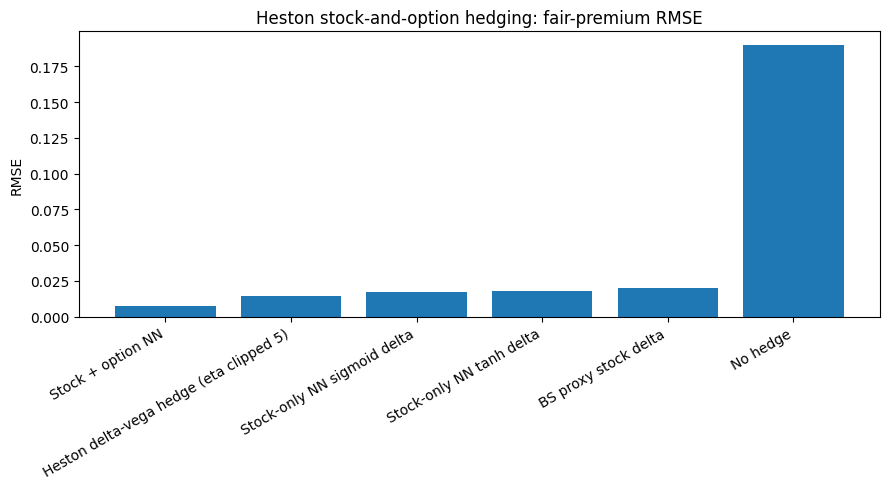

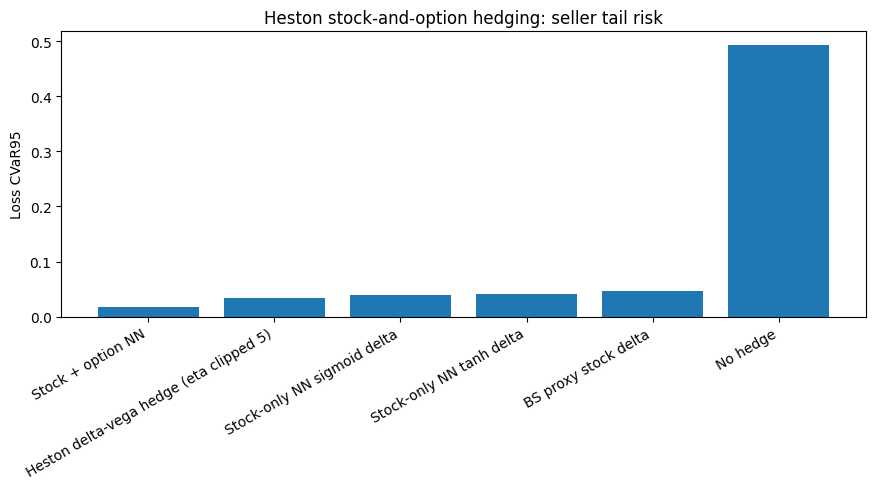

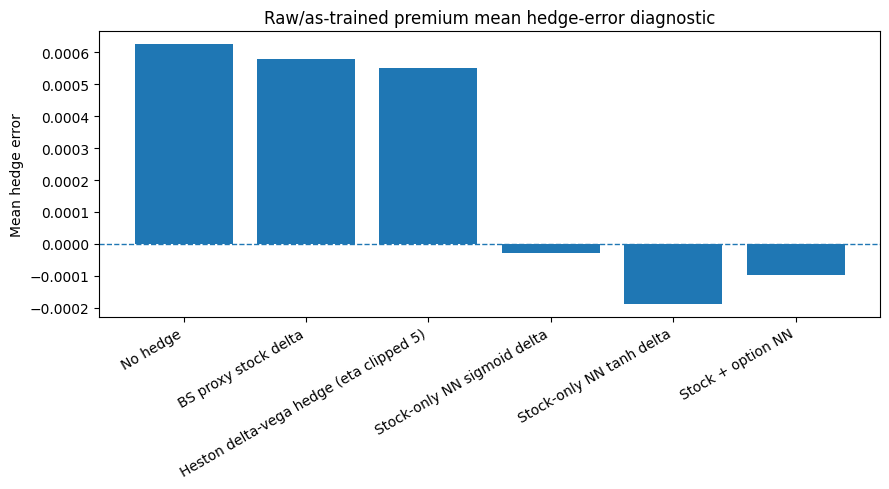

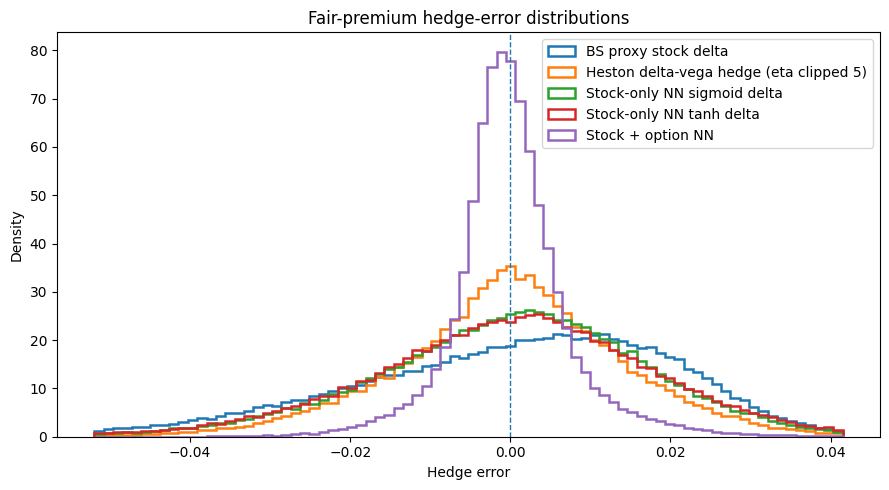

In [28]:

# ============================================================
# REVISION 5: Revised report figures
# ============================================================

# Fair-premium RMSE bar plot
plot_df = results_fair_df.sort_values("RMSE")
plt.figure(figsize=(9, 5))
plt.bar(plot_df["Strategy"], plot_df["RMSE"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("RMSE")
plt.title("Heston stock-and-option hedging: fair-premium RMSE")
plt.tight_layout()
plt.savefig(Path(OUTPUT_DIR) / "heston_revised_rmse_bar.png", dpi=200)
plt.show()

# Fair-premium Loss CVaR95
plot_df = results_fair_df.sort_values("Loss CVaR95")
plt.figure(figsize=(9, 5))
plt.bar(plot_df["Strategy"], plot_df["Loss CVaR95"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("Loss CVaR95")
plt.title("Heston stock-and-option hedging: seller tail risk")
plt.tight_layout()
plt.savefig(Path(OUTPUT_DIR) / "heston_revised_cvar95_bar.png", dpi=200)
plt.show()

# Raw Mean HE diagnostic
plt.figure(figsize=(9, 5))
plt.bar(results_raw_df["Strategy"], results_raw_df["Mean HE"])
plt.axhline(0.0, linestyle="--", linewidth=1.0)
plt.xticks(rotation=30, ha="right")
plt.ylabel("Mean hedge error")
plt.title("Raw/as-trained premium mean hedge-error diagnostic")
plt.tight_layout()
plt.savefig(Path(OUTPUT_DIR) / "heston_revised_raw_mean_he_bar.png", dpi=200)
plt.show()

# Fair-premium hedge-error histograms
he_dict = {}
with torch.no_grad():
    for name, gains, pos, premium in strategy_objects:
        fair_premium = torch.mean(payoff_test - gains)
        he = fair_premium + gains - payoff_test
        he_dict[name] = he.detach().cpu().numpy()

key_names = [
    "BS proxy stock delta",
    f"Heston delta-vega hedge (eta clipped {ETA_CLIP:g})",
    "Stock-only NN sigmoid delta",
    "Stock-only NN tanh delta",
    "Stock + option NN",
]

all_he = np.concatenate([he_dict[k] for k in key_names])
lo, hi = np.quantile(all_he, [0.005, 0.995])

plt.figure(figsize=(9, 5))
for name in key_names:
    plt.hist(he_dict[name], bins=80, range=(lo, hi), density=True, histtype="step", linewidth=1.8, label=name)
plt.axvline(0.0, linestyle="--", linewidth=1.0)
plt.xlabel("Hedge error")
plt.ylabel("Density")
plt.title("Fair-premium hedge-error distributions")
plt.legend()
plt.tight_layout()
plt.savefig(Path(OUTPUT_DIR) / "heston_revised_hedge_error_histograms.png", dpi=200)
plt.show()


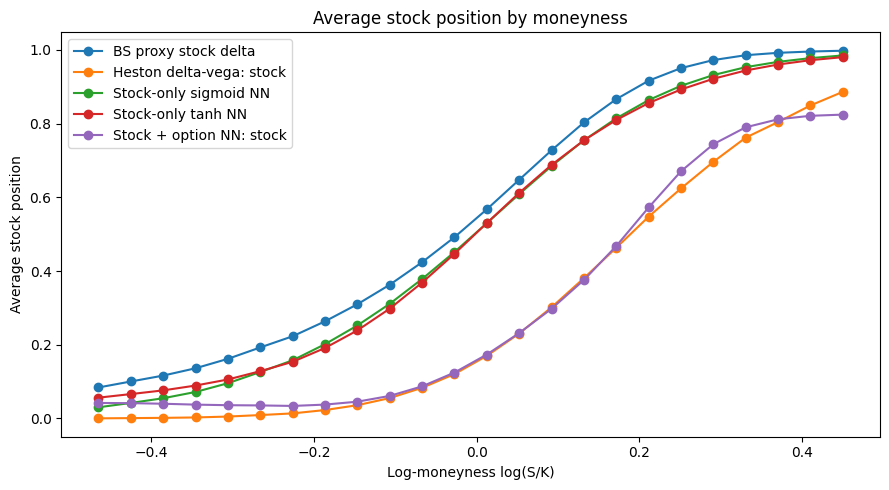

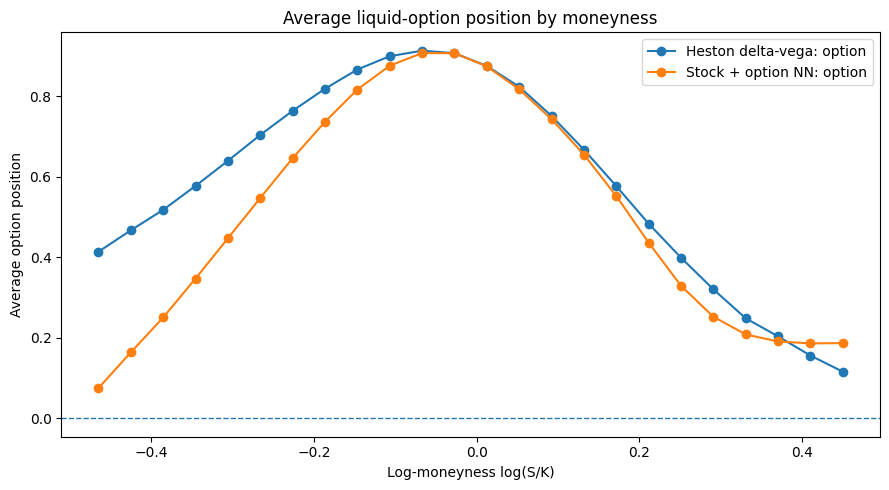

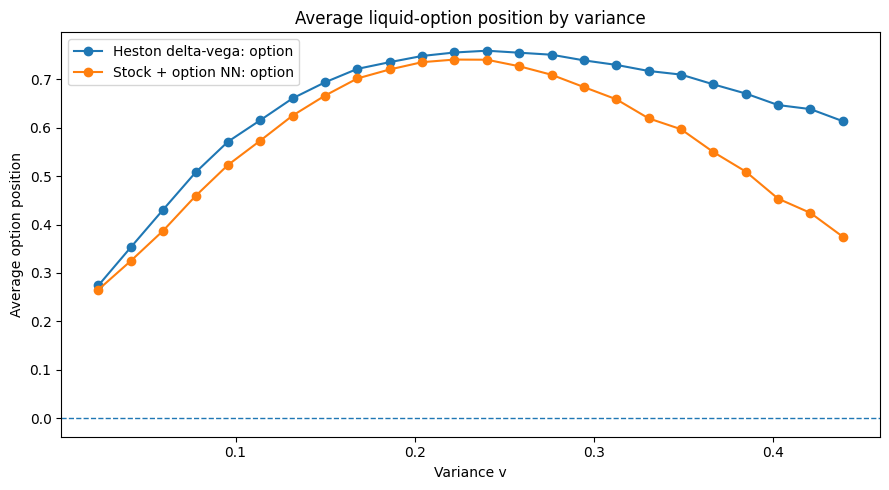

,variance_mid,proxy_delta_vega_eta,stock_option_nn_eta
0,0.023450,0.274587,0.265899
1,0.041520,0.353166,0.325086
2,0.059590,0.430886,0.387480
3,0.077661,0.507662,0.459021
4,0.095731,0.571053,0.522914


In [29]:

# ============================================================
# REVISION 6: Position diagnostics for vega-interpretation check
# ============================================================

@torch.no_grad()
def binned_positions_by_variable_revision(var_np, positions, time_index, n_bins=25):
    delta = positions["delta"][:, time_index].detach().cpu().numpy()
    eta = positions["eta"][:, time_index].detach().cpu().numpy()

    bins = np.linspace(np.quantile(var_np, 0.01), np.quantile(var_np, 0.99), n_bins)
    mids = 0.5 * (bins[:-1] + bins[1:])
    avg_delta, avg_eta = [], []

    for a, b in zip(bins[:-1], bins[1:]):
        mask = (var_np >= a) & (var_np < b)
        if mask.sum() == 0:
            avg_delta.append(np.nan)
            avg_eta.append(np.nan)
        else:
            avg_delta.append(np.mean(delta[mask]))
            avg_eta.append(np.mean(eta[mask]))

    return mids, np.array(avg_delta), np.array(avg_eta)

mid_index = N_STEPS // 2
log_m = torch.log(S_test[:, mid_index] / K_TARGET).detach().cpu().numpy()
variance_mid = v_test[:, mid_index].detach().cpu().numpy()

m_mids, sig_delta_m, _ = binned_positions_by_variable_revision(log_m, pos_stock_sigmoid, mid_index)
_, tanh_delta_m, _ = binned_positions_by_variable_revision(log_m, pos_stock_tanh, mid_index)
_, so_delta_m, so_eta_m = binned_positions_by_variable_revision(log_m, pos_stock_option, mid_index)
_, proxy_delta_m, _ = binned_positions_by_variable_revision(log_m, {"delta": proxy_delta, "eta": proxy_eta_zero}, mid_index)
_, dv_delta_m, dv_eta_m = binned_positions_by_variable_revision(log_m, {"delta": dv_delta, "eta": dv_eta}, mid_index)

plt.figure(figsize=(9, 5))
plt.plot(m_mids, proxy_delta_m, marker="o", label="BS proxy stock delta")
plt.plot(m_mids, dv_delta_m, marker="o", label="Heston delta-vega: stock")
plt.plot(m_mids, sig_delta_m, marker="o", label="Stock-only sigmoid NN")
plt.plot(m_mids, tanh_delta_m, marker="o", label="Stock-only tanh NN")
plt.plot(m_mids, so_delta_m, marker="o", label="Stock + option NN: stock")
plt.xlabel("Log-moneyness log(S/K)")
plt.ylabel("Average stock position")
plt.title("Average stock position by moneyness")
plt.legend()
plt.tight_layout()
plt.savefig(Path(OUTPUT_DIR) / "heston_revised_stock_position_by_moneyness.png", dpi=200)
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(m_mids, dv_eta_m, marker="o", label="Heston delta-vega: option")
plt.plot(m_mids, so_eta_m, marker="o", label="Stock + option NN: option")
plt.axhline(0.0, linestyle="--", linewidth=1.0)
plt.xlabel("Log-moneyness log(S/K)")
plt.ylabel("Average option position")
plt.title("Average liquid-option position by moneyness")
plt.legend()
plt.tight_layout()
plt.savefig(Path(OUTPUT_DIR) / "heston_revised_option_position_by_moneyness.png", dpi=200)
plt.show()

v_mids, _, so_eta_v = binned_positions_by_variable_revision(variance_mid, pos_stock_option, mid_index)
_, _, dv_eta_v = binned_positions_by_variable_revision(variance_mid, {"delta": dv_delta, "eta": dv_eta}, mid_index)

plt.figure(figsize=(9, 5))
plt.plot(v_mids, dv_eta_v, marker="o", label="Heston delta-vega: option")
plt.plot(v_mids, so_eta_v, marker="o", label="Stock + option NN: option")
plt.axhline(0.0, linestyle="--", linewidth=1.0)
plt.xlabel("Variance v")
plt.ylabel("Average option position")
plt.title("Average liquid-option position by variance")
plt.legend()
plt.tight_layout()
plt.savefig(Path(OUTPUT_DIR) / "heston_revised_option_position_by_variance.png", dpi=200)
plt.show()

variance_position_df = pd.DataFrame({
    "variance_mid": v_mids,
    "proxy_delta_vega_eta": dv_eta_v,
    "stock_option_nn_eta": so_eta_v,
})
variance_position_df.to_csv(Path(OUTPUT_DIR) / "heston_revised_option_position_by_variance.csv", index=False)
display(variance_position_df.head())


In [30]:

# ============================================================
# REVISION 7: LaTeX helpers and output manifest
# ============================================================

latex_cols = [
    "Strategy",
    "Premium",
    "RMSE",
    "Mean HE",
    "Loss CVaR95",
    "Loss CVaR99",
    "Mean abs delta",
    "Mean abs eta",
    "Mean stock turnover",
    "Mean option turnover",
]

print("Fair-premium main table:")
print(results_fair_df[latex_cols].to_latex(index=False, float_format=lambda x: f"{x:.6f}", escape=False))

print("\nRaw/as-trained premium diagnostic table:")
print(results_raw_df[["Strategy", "Premium", "RMSE", "Mean HE", "Loss CVaR95"]].to_latex(
    index=False,
    float_format=lambda x: f"{x:.6f}",
    escape=False,
))

manifest = pd.DataFrame([
    {"File": str(Path(OUTPUT_DIR) / "heston_revised_results_fair_premium.csv"), "Use": "Main fair-premium results table"},
    {"File": str(Path(OUTPUT_DIR) / "heston_revised_results_raw_premium.csv"), "Use": "Raw/as-trained premium diagnostics"},
    {"File": str(Path(OUTPUT_DIR) / "heston_proxy_option_drift_diagnostics.csv"), "Use": "Proxy option drift diagnostic"},
    {"File": str(Path(OUTPUT_DIR) / "heston_revised_improvement_summary.csv"), "Use": "Improvement and parametrization-confound summary"},
    {"File": str(Path(OUTPUT_DIR) / "heston_eta_saturation_diagnostics.csv"), "Use": "Option-position rail saturation diagnostic"},
    {"File": str(Path(OUTPUT_DIR) / "heston_delta_vega_clip_sensitivity.csv"), "Use": "Wider-clip sensitivity for Heston COS delta-vega benchmark"},
    {"File": str(Path(OUTPUT_DIR) / "heston_delta_vega_clip_saturation.csv"), "Use": "Clip-binding diagnostic for primary and wider Heston COS delta-vega benchmarks"},
    {"File": str(Path(OUTPUT_DIR) / "heston_delta_vega_clip_sensitivity_note.txt"), "Use": "Suggested reporting interpretation for clip sensitivity"},
    {"File": str(Path(OUTPUT_DIR) / "heston_same_path_bs_proxy_delta_vega_fair.csv"), "Use": "Same-path diagnostic: old BS-proxy delta-vega rule, fair-premium evaluation"},
    {"File": str(Path(OUTPUT_DIR) / "heston_same_path_bs_proxy_delta_vega_raw.csv"), "Use": "Same-path diagnostic: old BS-proxy delta-vega rule, raw-premium evaluation"},
    {"File": str(Path(OUTPUT_DIR) / "heston_same_path_bs_proxy_option_drift.csv"), "Use": "Same-path diagnostic: BS-proxy vs COS liquid-option drift"},
    {"File": str(Path(OUTPUT_DIR) / "heston_same_path_bs_proxy_eta_saturation.csv"), "Use": "Same-path diagnostic: option-position saturation for BS proxy, COS benchmark, and NN"},
    {"File": str(Path(OUTPUT_DIR) / "heston_same_path_bs_proxy_comparison_summary.csv"), "Use": "Same-path diagnostic: proxy/COS benchmark comparison against stock+option NN"},
    {"File": str(Path(OUTPUT_DIR) / "heston_same_path_bs_proxy_reconciliation_note.txt"), "Use": "Suggested reporting guidance for same-path BS-proxy diagnostic"},
    {"File": str(Path(OUTPUT_DIR) / "heston_multiseed_headline_fair.csv"), "Use": "Multi-seed fair-premium results for headline Heston COS comparisons"},
    {"File": str(Path(OUTPUT_DIR) / "heston_multiseed_training_diagnostics.csv"), "Use": "Multi-seed neural training diagnostics"},
    {"File": str(Path(OUTPUT_DIR) / "heston_multiseed_pairwise_improvements.csv"), "Use": "Per-seed pairwise improvements against stock-only and analytic benchmarks"},
    {"File": str(Path(OUTPUT_DIR) / "heston_multiseed_headline_summary.csv"), "Use": "Multi-seed mean/std/min/max headline summary"},
    {"File": str(Path(OUTPUT_DIR) / "heston_multiseed_pairwise_summary.csv"), "Use": "Multi-seed pairwise summary for report wording"},
    {"File": str(Path(OUTPUT_DIR) / "heston_multiseed_report_note.txt"), "Use": "Text summary for Heston COS report integration"},


    {"File": str(Path(OUTPUT_DIR) / "heston_revised_rmse_bar.png"), "Use": "Main RMSE figure"},
    {"File": str(Path(OUTPUT_DIR) / "heston_revised_cvar95_bar.png"), "Use": "Main Loss CVaR95 figure"},
    {"File": str(Path(OUTPUT_DIR) / "heston_revised_raw_mean_he_bar.png"), "Use": "Raw Mean HE diagnostic figure"},
    {"File": str(Path(OUTPUT_DIR) / "heston_revised_option_position_by_variance.png"), "Use": "Vega interpretation diagnostic"},
    {"File": str(Path(OUTPUT_DIR) / "heston_revised_hedge_error_histograms.png"), "Use": "Optional hedge-error histogram"},
    {"File": str(Path(OUTPUT_DIR) / "heston_revised_stock_position_by_moneyness.png"), "Use": "Optional stock-position diagnostic"},
    {"File": str(Path(OUTPUT_DIR) / "heston_revised_option_position_by_moneyness.png"), "Use": "Optional option-position diagnostic"},
])
manifest.to_csv(Path(OUTPUT_DIR) / "heston_revised_report_output_manifest.csv", index=False)
display(manifest)


Fair-premium main table:
\begin{tabular}{lrrrrrrrrr}
\toprule
Strategy & Premium & RMSE & Mean HE & Loss CVaR95 & Loss CVaR99 & Mean abs delta & Mean abs eta & Mean stock turnover & Mean option turnover \\
\midrule
No hedge & 0.164789 & 0.190061 & -0.000000 & 0.492959 & 0.673346 & 0.000000 & 0.000000 & 0.000000 & 0.000000 \\
BS proxy stock delta & 0.164836 & 0.019997 & -0.000000 & 0.046360 & 0.060874 & 0.682122 & 0.000000 & 3.894743 & 0.000000 \\
Heston delta-vega hedge (eta clipped 5) & 0.164862 & 0.014782 & -0.000000 & 0.033251 & 0.046416 & 0.386796 & 0.603444 & 5.392436 & 7.131248 \\
Stock-only NN sigmoid delta & 0.164849 & 0.017325 & -0.000000 & 0.039931 & 0.055640 & 0.646223 & 0.000000 & 3.820175 & 0.000000 \\
Stock-only NN tanh delta & 0.164863 & 0.018166 & -0.000000 & 0.041379 & 0.058373 & 0.645336 & 0.000000 & 3.845603 & 0.000000 \\
Stock + option NN & 0.164894 & 0.007426 & -0.000000 & 0.016624 & 0.024619 & 0.368615 & 0.599272 & 3.122542 & 4.691251 \\
\bottomrule
\end{tabular}


,File,Use
0,heston_delta_vega_outputs/heston_revised_resul...,Main fair-premium results table
1,heston_delta_vega_outputs/heston_revised_resul...,Raw/as-trained premium diagnostics
2,heston_delta_vega_outputs/heston_proxy_option_...,Proxy option drift diagnostic
3,heston_delta_vega_outputs/heston_revised_impro...,Improvement and parametrization-confound summary
4,heston_delta_vega_outputs/heston_eta_saturatio...,Option-position rail saturation diagnostic
5,heston_delta_vega_outputs/heston_delta_vega_cl...,Wider-clip sensitivity for Heston COS delta-ve...
6,heston_delta_vega_outputs/heston_delta_vega_cl...,Clip-binding diagnostic for primary and wider ...
7,heston_delta_vega_outputs/heston_delta_vega_cl...,Suggested reporting interpretation for clip se...
8,heston_delta_vega_outputs/heston_same_path_bs_...,Same-path diagnostic: old BS-proxy delta-vega ...
9,heston_delta_vega_outputs/heston_same_path_bs_...,Same-path diagnostic: old BS-proxy delta-vega ...


## Multi-seed headline robustness check

This cell is enabled for the A100 rerun. It retrains the two load-bearing neural models across several independent seeds and evaluates them against the analytic rules on the same path realisation for each seed.

The key comparison is now the stock + option NN against the strongest analytic heuristic tested in the COS experiment: the frozen-volatility BS-proxy Greek rule marked to the COS-priced liquid-option path. The Heston COS delta--vega benchmark is also included as the primary model-consistent local Greek benchmark.


In [31]:

# ============================================================
# REVISION 8: Multi-seed headline robustness check
# ============================================================

RUN_MULTI_SEED_HEADLINE = True

# Three seeds is usually enough for a concise dissertation robustness check.
# Increase only if there is time; each seed retrains the stock-only tanh NN and
# the stock+option NN and re-evaluates the analytic benchmarks.
MULTI_SEEDS = [111, 222, 333]

# Use the same sizes as the active notebook configuration.
# With RUN_FULL=True this uses 100k/25k/100k paths per seed.
MULTI_N_TRAIN = N_TRAIN
MULTI_N_VAL = N_VAL
MULTI_N_TEST = N_TEST
MULTI_MAX_EPOCHS = MAX_EPOCHS

def _multi_seed_prepare_variance_inputs(S_tr, v_tr_true, C_tr,
                                        S_va, v_va_true, C_va,
                                        S_te, v_te_true, C_te,
                                        times_grid):
    """
    Match the main experiment's information setting.
    C_h is always the traded COS price path. If USE_OBSERVABLE_VOL=True, hedge inputs
    and analytic Greeks condition on an EWMA variance proxy; otherwise they use true v.
    """
    if USE_OBSERVABLE_VOL:
        v_tr_in = ewma_realized_variance(S_tr, times_grid)
        v_va_in = ewma_realized_variance(S_va, times_grid)
        v_te_in = ewma_realized_variance(S_te, times_grid)
    else:
        v_tr_in, v_va_in, v_te_in = v_tr_true, v_va_true, v_te_true
    return v_tr_in, v_va_in, v_te_in

def _train_model_with_seed(model_class, model_kwargs, kind,
                           S_tr, v_tr, C_tr, y_tr,
                           S_va, v_va, C_va, y_va,
                           times_grid, init_seed, train_seed,
                           max_epochs=None):
    """
    Construct and train one model with controlled initialization and minibatch seeds.
    kind: 'stock' or 'stock_option'
    """
    if max_epochs is None:
        max_epochs = MULTI_MAX_EPOCHS

    torch.manual_seed(init_seed)
    model = model_class(**model_kwargs).to(device)

    torch.manual_seed(train_seed)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

    best_val = float("inf")
    best_state = None
    bad_epochs = 0
    n = S_tr.shape[0]
    stopped_epoch = max_epochs

    for epoch in range(1, max_epochs + 1):
        model.train()
        perm = torch.randperm(n, device=device)

        for start in range(0, n, BATCH_SIZE):
            idx = perm[start:start+BATCH_SIZE]
            optimizer.zero_grad()

            if kind == "stock":
                he, _ = hedge_error_stock_only(model, S_tr[idx], v_tr[idx], C_tr[idx], y_tr[idx], times_grid)
            elif kind == "stock_option":
                he, _ = hedge_error_stock_option(model, S_tr[idx], v_tr[idx], C_tr[idx], y_tr[idx], times_grid)
            else:
                raise ValueError("kind must be 'stock' or 'stock_option'")

            loss = torch.mean(he ** 2)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()

        model.eval()
        with torch.no_grad():
            if kind == "stock":
                he_val, _ = hedge_error_stock_only(model, S_va, v_va, C_va, y_va, times_grid)
            else:
                he_val, _ = hedge_error_stock_option(model, S_va, v_va, C_va, y_va, times_grid)
            val_loss = float(torch.mean(he_val ** 2).detach().cpu())

        if val_loss < best_val - 1e-10:
            best_val = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1

        if epoch == 1 or epoch % 10 == 0:
            print(
                f"    {model_class.__name__} epoch {epoch:03d} | "
                f"val_loss={val_loss:.6e} | best={best_val:.6e}"
            )

        if bad_epochs >= PATIENCE:
            stopped_epoch = epoch
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, {"best_val_loss": best_val, "stopped_epoch": stopped_epoch}

def _summarize_seed_strategy(strategy_name, gains, positions, payoff):
    """
    Fair-premium summary for one seed.
    """
    fair_premium = torch.mean(payoff - gains)
    he = fair_premium + gains - payoff
    he_np = he.detach().cpu().numpy()
    loss = -he_np

    def cvar_upper(x, alpha):
        q = np.quantile(x, alpha)
        return x[x >= q].mean()

    delta = positions["delta"]
    eta = positions["eta"]

    return {
        "Strategy": strategy_name,
        "Fair premium": float(fair_premium.detach().cpu()),
        "RMSE": float(np.sqrt(np.mean(he_np**2))),
        "Loss CVaR95": float(cvar_upper(loss, 0.95)),
        "Loss CVaR99": float(cvar_upper(loss, 0.99)),
        "Mean abs delta": float(torch.mean(torch.abs(delta)).detach().cpu()),
        "Mean abs eta": float(torch.mean(torch.abs(eta)).detach().cpu()),
        "Max abs eta": float(torch.max(torch.abs(eta)).detach().cpu()),
    }

def _append_multiseed_pairwise(seed, strategy_rows):
    """
    Compute per-seed improvement of stock+option NN over the main competitors.
    """
    rows_by_name = {r["Strategy"]: r for r in strategy_rows}
    nn = rows_by_name["Stock + option NN"]

    competitors = [
        "Stock-only NN tanh delta",
        "BS-proxy Greeks on COS option path",
        "Heston COS delta-vega benchmark",
    ]

    out_rows = []
    for comp in competitors:
        c = rows_by_name[comp]
        out_rows.append({
            "Seed": seed,
            "Comparison": f"Stock + option NN vs {comp}",
            "Competitor RMSE": c["RMSE"],
            "Stock+option NN RMSE": nn["RMSE"],
            "RMSE improvement (%)": 100.0 * (c["RMSE"] - nn["RMSE"]) / c["RMSE"],
            "Competitor Loss CVaR95": c["Loss CVaR95"],
            "Stock+option NN Loss CVaR95": nn["Loss CVaR95"],
            "Loss CVaR95 improvement (%)": 100.0 * (c["Loss CVaR95"] - nn["Loss CVaR95"]) / c["Loss CVaR95"],
            "NN beats competitor on RMSE": bool(nn["RMSE"] < c["RMSE"]),
            "NN beats competitor on Loss CVaR95": bool(nn["Loss CVaR95"] < c["Loss CVaR95"]),
        })
    return out_rows

if RUN_MULTI_SEED_HEADLINE:
    multi_seed_rows = []
    multi_seed_training_rows = []
    multi_seed_pairwise_rows = []

    for seed_idx, base_seed in enumerate(MULTI_SEEDS, start=1):
        print("=" * 72)
        print(f"Multi-seed headline run {seed_idx}/{len(MULTI_SEEDS)} | base seed {base_seed}")
        print("=" * 72)

        # Simulate fresh train/val/test sets for this seed.
        S_tr, v_tr_true, C_tr, t_grid = simulate_heston_paths(MULTI_N_TRAIN, base_seed + 1)
        S_va, v_va_true, C_va, _ = simulate_heston_paths(MULTI_N_VAL, base_seed + 2)
        S_te, v_te_true, C_te, _ = simulate_heston_paths(MULTI_N_TEST, base_seed + 3)

        v_tr, v_va, v_te = _multi_seed_prepare_variance_inputs(
            S_tr, v_tr_true, C_tr,
            S_va, v_va_true, C_va,
            S_te, v_te_true, C_te,
            t_grid,
        )

        y_tr = torch.clamp(S_tr[:, -1] - K_TARGET, min=0.0)
        y_va = torch.clamp(S_va[:, -1] - K_TARGET, min=0.0)
        y_te = torch.clamp(S_te[:, -1] - K_TARGET, min=0.0)

        # Model constructors initialize the learned premium from target_premium_mc.
        # This assignment is intentional and local to the current seed's training setup.
        target_premium_mc = float(torch.mean(y_tr).detach().cpu())

        # --------------------------
        # Analytic benchmarks
        # --------------------------
        with torch.no_grad():
            # Heston COS local Greek benchmark: primary model-consistent local benchmark.
            cos_dv_delta, cos_dv_eta = heston_delta_vega_positions(
                S_te, v_te, t_grid, HESTON_PARAMS,
                K_TARGET, T_TARGET, K_HEDGE, T_HEDGE,
                delta_clip=DELTA_CLIP,
                eta_clip=ETA_CLIP,
            )
            cos_dv_gains = gains_from_positions_revision(cos_dv_delta, cos_dv_eta, S_te, C_te)
            cos_dv_row = _summarize_seed_strategy(
                "Heston COS delta-vega benchmark",
                cos_dv_gains,
                {"delta": cos_dv_delta, "eta": cos_dv_eta},
                y_te,
            )

            # Strongest same-path heuristic: BS-proxy Greeks marked to the COS option path.
            bs_dv_delta, bs_dv_eta = bs_proxy_delta_vega_positions(
                S_te, v_te, t_grid,
                delta_clip=DELTA_CLIP,
                eta_clip=ETA_CLIP,
            )
            bs_on_cos_gains = gains_from_positions_revision(bs_dv_delta, bs_dv_eta, S_te, C_te)
            bs_on_cos_row = _summarize_seed_strategy(
                "BS-proxy Greeks on COS option path",
                bs_on_cos_gains,
                {"delta": bs_dv_delta, "eta": bs_dv_eta},
                y_te,
            )

        # --------------------------
        # Neural headline models
        # --------------------------
        print("  Training stock-only tanh NN")
        m_tanh, tanh_train_info = _train_model_with_seed(
            StockOnlyHestonTanhNN,
            {"hidden_width": HIDDEN_WIDTH, "hidden_depth": HIDDEN_DEPTH, "delta_scale": DELTA_SCALE},
            "stock",
            S_tr, v_tr, C_tr, y_tr,
            S_va, v_va, C_va, y_va,
            t_grid,
            init_seed=base_seed + 10,
            train_seed=base_seed + 11,
            max_epochs=MULTI_MAX_EPOCHS,
        )

        print("  Training stock + option NN")
        m_so, so_train_info = _train_model_with_seed(
            StockOptionHestonNN,
            {"hidden_width": HIDDEN_WIDTH, "hidden_depth": HIDDEN_DEPTH,
             "delta_scale": DELTA_SCALE, "eta_scale": ETA_SCALE},
            "stock_option",
            S_tr, v_tr, C_tr, y_tr,
            S_va, v_va, C_va, y_va,
            t_grid,
            init_seed=base_seed + 20,
            train_seed=base_seed + 21,
            max_epochs=MULTI_MAX_EPOCHS,
        )

        with torch.no_grad():
            gains_tanh, pos_tanh_ms = gains_stock_only_model_revision(m_tanh, S_te, v_te, C_te, y_te, t_grid)
            gains_so, pos_so_ms = gains_stock_option_model_revision(m_so, S_te, v_te, C_te, y_te, t_grid)

        tanh_row = _summarize_seed_strategy(
            "Stock-only NN tanh delta",
            gains_tanh,
            pos_tanh_ms,
            y_te,
        )
        so_row = _summarize_seed_strategy(
            "Stock + option NN",
            gains_so,
            pos_so_ms,
            y_te,
        )

        seed_rows = [tanh_row, bs_on_cos_row, cos_dv_row, so_row]
        for row in seed_rows:
            row["Seed"] = base_seed
            row["Information setting"] = "observable EWMA variance" if USE_OBSERVABLE_VOL else "full-information true variance"
            row["N_train"] = MULTI_N_TRAIN
            row["N_val"] = MULTI_N_VAL
            row["N_test"] = MULTI_N_TEST
            row["Max epochs"] = MULTI_MAX_EPOCHS
            multi_seed_rows.append(row)

        multi_seed_training_rows.extend([
            {
                "Seed": base_seed,
                "Strategy": "Stock-only NN tanh delta",
                **tanh_train_info,
            },
            {
                "Seed": base_seed,
                "Strategy": "Stock + option NN",
                **so_train_info,
            },
        ])

        multi_seed_pairwise_rows.extend(_append_multiseed_pairwise(base_seed, seed_rows))

        # Keep GPU memory under control before the next seed.
        del S_tr, v_tr_true, C_tr, S_va, v_va_true, C_va, S_te, v_te_true, C_te
        del v_tr, v_va, v_te, y_tr, y_va, y_te
        del m_tanh, m_so
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    multi_seed_df = pd.DataFrame(multi_seed_rows)
    multi_seed_training_df = pd.DataFrame(multi_seed_training_rows)
    multi_seed_pairwise_df = pd.DataFrame(multi_seed_pairwise_rows)

    multi_seed_summary = (
        multi_seed_df
        .groupby("Strategy")[["RMSE", "Loss CVaR95", "Loss CVaR99", "Mean abs eta", "Max abs eta"]]
        .agg(["mean", "std", "min", "max"])
    )

    pairwise_summary = (
        multi_seed_pairwise_df
        .groupby("Comparison")[[
            "RMSE improvement (%)",
            "Loss CVaR95 improvement (%)",
            "NN beats competitor on RMSE",
            "NN beats competitor on Loss CVaR95",
        ]]
        .agg({
            "RMSE improvement (%)": ["mean", "std", "min", "max"],
            "Loss CVaR95 improvement (%)": ["mean", "std", "min", "max"],
            "NN beats competitor on RMSE": ["mean", "sum"],
            "NN beats competitor on Loss CVaR95": ["mean", "sum"],
        })
    )

    multi_seed_df.to_csv(Path(OUTPUT_DIR) / "heston_multiseed_headline_fair.csv", index=False)
    multi_seed_training_df.to_csv(Path(OUTPUT_DIR) / "heston_multiseed_training_diagnostics.csv", index=False)
    multi_seed_pairwise_df.to_csv(Path(OUTPUT_DIR) / "heston_multiseed_pairwise_improvements.csv", index=False)
    multi_seed_summary.to_csv(Path(OUTPUT_DIR) / "heston_multiseed_headline_summary.csv")
    pairwise_summary.to_csv(Path(OUTPUT_DIR) / "heston_multiseed_pairwise_summary.csv")

    # A compact text note for the report-writing step.
    best_heuristic_comp = multi_seed_pairwise_df[
        multi_seed_pairwise_df["Comparison"] == "Stock + option NN vs BS-proxy Greeks on COS option path"
    ]
    cos_comp = multi_seed_pairwise_df[
        multi_seed_pairwise_df["Comparison"] == "Stock + option NN vs Heston COS delta-vega benchmark"
    ]
    tanh_comp = multi_seed_pairwise_df[
        multi_seed_pairwise_df["Comparison"] == "Stock + option NN vs Stock-only NN tanh delta"
    ]

    note_lines = [
        "Heston COS multi-seed headline robustness check",
        "================================================",
        "",
        f"Seeds: {MULTI_SEEDS}",
        f"Path sizes per seed: train={MULTI_N_TRAIN}, val={MULTI_N_VAL}, test={MULTI_N_TEST}",
        f"Information setting: {'observable EWMA variance' if USE_OBSERVABLE_VOL else 'full-information true variance'}",
        "",
        "Main pairwise finding:",
        (
            "Stock + option NN vs BS-proxy Greeks on COS option path: "
            f"mean RMSE improvement = {best_heuristic_comp['RMSE improvement (%)'].mean():.2f}%, "
            f"min = {best_heuristic_comp['RMSE improvement (%)'].min():.2f}%, "
            f"max = {best_heuristic_comp['RMSE improvement (%)'].max():.2f}%, "
            f"RMSE wins = {int(best_heuristic_comp['NN beats competitor on RMSE'].sum())}/{len(best_heuristic_comp)}."
        ),
        (
            "Stock + option NN vs Heston COS delta-vega benchmark: "
            f"mean RMSE improvement = {cos_comp['RMSE improvement (%)'].mean():.2f}%, "
            f"RMSE wins = {int(cos_comp['NN beats competitor on RMSE'].sum())}/{len(cos_comp)}."
        ),
        (
            "Stock + option NN vs stock-only tanh NN: "
            f"mean RMSE improvement = {tanh_comp['RMSE improvement (%)'].mean():.2f}%, "
            f"RMSE wins = {int(tanh_comp['NN beats competitor on RMSE'].sum())}/{len(tanh_comp)}."
        ),
        "",
        "Reporting guidance:",
        "- Use the BS-proxy-Greeks-on-COS-path row as the strongest analytic heuristic comparison.",
        "- Use the Heston COS delta-vega row as the primary model-consistent local Greek benchmark.",
        "- Do not claim dominance over the unknown finite-grid MSE-optimal Heston hedge.",
    ]
    Path(OUTPUT_DIR, "heston_multiseed_report_note.txt").write_text("\n".join(note_lines), encoding="utf-8")

    print("Multi-seed headline fair results:")
    display(multi_seed_df)

    print("Multi-seed strategy summary:")
    display(multi_seed_summary)

    print("Multi-seed pairwise improvements:")
    display(multi_seed_pairwise_df)

    print("Multi-seed pairwise summary:")
    display(pairwise_summary)

    print("Training diagnostics:")
    display(multi_seed_training_df)

    print("Saved:")
    print(Path(OUTPUT_DIR) / "heston_multiseed_headline_fair.csv")
    print(Path(OUTPUT_DIR) / "heston_multiseed_training_diagnostics.csv")
    print(Path(OUTPUT_DIR) / "heston_multiseed_pairwise_improvements.csv")
    print(Path(OUTPUT_DIR) / "heston_multiseed_headline_summary.csv")
    print(Path(OUTPUT_DIR) / "heston_multiseed_pairwise_summary.csv")
    print(Path(OUTPUT_DIR) / "heston_multiseed_report_note.txt")
else:
    print("RUN_MULTI_SEED_HEADLINE is False. Set it to True to run the multi-seed headline robustness check.")


Multi-seed headline run 1/3 | base seed 111


  Training stock-only tanh NN


    StockOnlyHestonTanhNN epoch 001 | val_loss=1.046425e-03 | best=1.046425e-03


    StockOnlyHestonTanhNN epoch 010 | val_loss=8.323463e-04 | best=8.323463e-04


    StockOnlyHestonTanhNN epoch 020 | val_loss=6.171615e-04 | best=6.171615e-04


...

Multi-seed pairwise summary:


RMSE improvement (%)  \
                                                                   mean   
Comparison                                                                
Stock + option NN vs BS-proxy Greeks on COS opt...            22.675960   
Stock + option NN vs Heston COS delta-vega benc...            48.499985   
Stock + option NN vs Stock-only NN tanh delta                 57.839593   

                                                                         \
                                                         std        min   
Comparison                                                                
Stock + option NN vs BS-proxy Greeks on COS opt...  2.545023  20.647386   
Stock + option NN vs Heston COS delta-vega benc...  1.746126  47.296318   
Stock + option NN vs Stock-only NN tanh delta       1.628560  55.959414   

                                                               \
                                                          max   
Comparison                                                      
Stock + option NN vs BS-proxy Greeks on COS opt...  25.531662   
Stock + option NN vs Heston COS delta-vega benc...  50.502656   
Stock + option NN vs Stock-only NN tanh delta       58.809692   

                                                   Loss CVaR95 improvement (%)  \
                                                                          mean   
Comparison                                                                       
Stock + option NN vs BS-proxy Greeks on COS opt...                   27.127593   
Stock + option NN vs Heston COS delta-vega benc...                   49.399357   
Stock + option NN vs Stock-only NN tanh delta                        59.828460   

                                                                         \
                                                         std        min   
Comparison                                                                
Stock + option NN vs BS-proxy Greeks on COS opt...  0.852899  26.321491   
Stock + option NN vs Heston COS delta-vega benc...  0.486304  49.065816   
Stock + option NN vs Stock-only NN tanh delta       0.812879  58.892595   

                                                               \
                                                          max   
Comparison                                                      
Stock + option NN vs BS-proxy Greeks on COS opt...  28.020630   
Stock + option NN vs Heston COS delta-vega benc...  49.957349   
Stock + option NN vs Stock-only NN tanh delta       60.358758   

                                                   NN beats competitor on RMSE  \
                                                                          mean   
Comparison                                                                       
Stock + option NN vs BS-proxy Greeks on COS opt...                         1.0   
Stock + option NN vs Heston COS delta-vega benc...                         1.0   
Stock + option NN vs Stock-only NN tanh delta                              1.0   

                                                        \
                                                   sum   
Comparison                                               
Stock + option NN vs BS-proxy Greeks on COS opt...   3   
Stock + option NN vs Heston COS delta-vega benc...   3   
Stock + option NN vs Stock-only NN tanh delta        3   

                                                   NN beats competitor on Loss CVaR95  \
                                                                                 mean   
Comparison                                                                              
Stock + option NN vs BS-proxy Greeks on COS opt...                                1.0   
Stock + option NN vs Heston COS delta-vega benc...                                1.0   
Stock + option NN vs Stock-only NN tanh delta                                     1.0   

                                              

Training diagnostics:


,Seed,Strategy,best_val_loss,stopped_epoch
0,111,Stock-only NN tanh delta,0.000311,150
1,111,Stock + option NN,0.000060,150
2,222,Stock-only NN tanh delta,0.000351,150
3,222,Stock + option NN,0.000060,150
4,333,Stock-only NN tanh delta,0.000318,150
5,333,Stock + option NN,0.000055,150


Saved:
heston_delta_vega_outputs/heston_multiseed_headline_fair.csv
heston_delta_vega_outputs/heston_multiseed_training_diagnostics.csv
heston_delta_vega_outputs/heston_multiseed_pairwise_improvements.csv
heston_delta_vega_outputs/heston_multiseed_headline_summary.csv
heston_delta_vega_outputs/heston_multiseed_pairwise_summary.csv
heston_delta_vega_outputs/heston_multiseed_report_note.txt



## Corrected reporting guidance after technical review

Use the safer title unless the diagnostics strongly support the vega interpretation:

```latex
\subsection{Stock-and-Option Neural Hedging under Heston Dynamics}
```

The earlier guidance over-trusted raw Mean HE as a proxy-drift detector. That is now corrected.

### Why raw Mean HE is not a primary drift test

For fair-premium evaluation,

\[
\pi^*=\mathbb{E}[\Phi(S_T)-\text{gains}],
\]

so

\[
\mathbb{E}[HE_{\text{fair}}]
=
\pi^*+\mathbb{E}[\text{gains}]-\mathbb{E}[\Phi(S_T)]
=
0
\]

by construction for every strategy. The fair-premium table therefore cannot diagnose drift.

For a premium-learning neural model evaluated at its learned premium,

\[
\mathbb{E}[HE_{\text{raw}}]
=
\pi_{\text{learn}}-\pi^*.
\]

Thus raw Mean HE mostly measures whether the learned premium has converged to the MSE-optimal premium. A near-zero raw Mean HE for the NN does **not** prove that the proxy option drift is harmless.

Raw Mean HE is still useful as a corroborating diagnostic, especially for fixed-premium benchmarks, but it should not be used as the main decision rule for the stock+option NN.

### Correct decision tree

**Step 1: Check whether the proxy option has drift.**

Use:

```text
heston_proxy_option_drift_diagnostics.csv
```

Compare `Mean dC per step` and `Mean total dC over target horizon` with their reported standard errors.

- If the proxy drift is within about two standard errors of zero, the drift artifact is empirically small.
- If the proxy drift is statistically non-zero, then the proxy instrument is not martingale-consistent under the Heston simulation measure.

**Step 2: If drift exists, ask whether it contaminates the result.**

This notebook implements that definitive test by repricing the hedge option with a martingale-consistent Heston COS price and rerunning the stock+option comparison. The remaining diagnostic checks are now: (i) whether the COS-priced option drift is statistically negligible, and (ii) whether the Heston COS delta--vega benchmark is materially affected by the common position bound.

The supporting diagnostics included here are:

```text
heston_revised_option_position_by_variance.png
```

If the learned NN option-position curve is variance/moneyness-contingent and broadly tracks the proxy delta--vega curve, the vega-hedging interpretation is more plausible. If it is poorly aligned or behaves like a flat offset, then the mechanism is not conclusively identified.

**Step 3: Calibrate the claim.**

If the COS drift diagnostic is negligible and the performance gap survives the benchmark clip-sensitivity check, the more specific title

```latex
\subsection{Delta--Vega Neural Hedging under Heston Dynamics}
```

is defensible.

If the COS drift diagnostic or benchmark clip-sensitivity check materially weakens the interpretation, use the safer title:

```latex
\subsection{Stock-and-Option Neural Hedging under Heston Dynamics}
```

and state:

> The liquid option is priced using a Heston COS method, which removes the Black--Scholes proxy-pricing drift caveat up to Euler discretisation error. The results should still be interpreted cautiously because the Heston COS delta--vega row is a local Greek-matching benchmark, not the finite-grid MSE-optimal multi-instrument hedge, and because the full-information run conditions on the simulated variance state.

### Multi-seed reporting rule

Use the single-seed results only if the stock+option-vs-stock-only-tanh gap is clearly large.

If the RMSE/CVaR gap is small, run the optional multi-seed cell below and report mean \(\pm\) standard deviation, or min/max, for the headline strategies. This is especially important for CVaR99, which is noisy on a finite test set.


In [32]:
# Observable variance proxy fidelity diagnostic
# Uses held-out test rebalancing states, excluding t0 because v_hat is seeded at v0.

with torch.no_grad():
    v_hat = v_test[:, 1:-1].detach().cpu().numpy().reshape(-1)
    v_true = v_test_true[:, 1:-1].detach().cpu().numpy().reshape(-1)

corr = np.corrcoef(v_hat, v_true)[0, 1]
rmse = np.sqrt(np.mean((v_hat - v_true) ** 2))
mae = np.mean(np.abs(v_hat - v_true))
bias = np.mean(v_hat - v_true)
mean_true = np.mean(v_true)
rel_rmse = rmse / mean_true

proxy_fidelity_df = pd.DataFrame([{
    "Dataset": "test rebalancing states excluding t0",
    "Corr(v_hat, v_true)": corr,
    "RMSE(v_hat, v_true)": rmse,
    "MAE(v_hat, v_true)": mae,
    "Bias(v_hat - v_true)": bias,
    "Mean true variance": mean_true,
    "Relative RMSE": rel_rmse,
}])

proxy_fidelity_df.to_csv(
    Path(OUTPUT_DIR) / "heston_observable_variance_proxy_fidelity.csv",
    index=False,
)

display(proxy_fidelity_df)
print(Path(OUTPUT_DIR) / "heston_observable_variance_proxy_fidelity.csv")

,Dataset,"Corr(v_hat, v_true)","RMSE(v_hat, v_true)","MAE(v_hat, v_true)",Bias(v_hat - v_true),Mean true variance,Relative RMSE
0,test rebalancing states excluding t0,1.0,0.0,0.0,0.0,0.15985,0.0


heston_delta_vega_outputs/heston_observable_variance_proxy_fidelity.csv


## Mode-suffixed output archive

The same notebook can be run in full-information mode or observable-volatility mode. This final cell preserves mode-suffixed copies of generated outputs, reducing the risk that one mode overwrites the other in the shared output directory.

In [33]:
# ============================================================
# REVISION 9: Mode-suffixed output archive
# ============================================================

# Running the notebook in full-information mode and then in observable-vol mode
# can overwrite the same base filenames. This cell creates mode-suffixed copies
# of generated artifacts so both runs can be archived unambiguously.

MODE_TAG = "obsvol" if USE_OBSERVABLE_VOL else "fullinfo"


def _mode_suffixed_path(path, mode_tag=MODE_TAG):
    path = Path(path)
    return path.with_name(f"{path.stem}_{mode_tag}{path.suffix}")


def archive_mode_suffixed_outputs(output_dir=OUTPUT_DIR, mode_tag=MODE_TAG):
    output_dir = Path(output_dir)
    copied = []
    suffixes = {".csv", ".txt", ".png"}
    for path in sorted(output_dir.iterdir()):
        if path.suffix.lower() not in suffixes:
            continue
        # Skip files already mode-suffixed.
        if path.stem.endswith(f"_{mode_tag}") or path.stem.endswith("_fullinfo") or path.stem.endswith("_obsvol"):
            continue
        dest = _mode_suffixed_path(path, mode_tag)
        dest.write_bytes(path.read_bytes())
        copied.append(dest.name)
    print(f"Archived {len(copied)} files with mode suffix _{mode_tag} in {output_dir}")
    return copied


mode_suffixed_files = archive_mode_suffixed_outputs()
mode_archive_manifest = pd.DataFrame({"Mode": MODE_TAG, "ModeSuffixedFile": mode_suffixed_files})
mode_archive_manifest.to_csv(Path(OUTPUT_DIR) / f"heston_mode_suffixed_archive_manifest_{MODE_TAG}.csv", index=False)
print(Path(OUTPUT_DIR) / f"heston_mode_suffixed_archive_manifest_{MODE_TAG}.csv")


Archived 51 files with mode suffix _fullinfo in heston_delta_vega_outputs
heston_delta_vega_outputs/heston_mode_suffixed_archive_manifest_fullinfo.csv
